In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')


Carregando o dataset

In [2]:
df = pd.read_csv('../base_modelo.csv')
df.head()

,id,safra,y,VAR_1,VAR_2,VAR_3,VAR_4,VAR_5,VAR_6,VAR_7,...,VAR_69,VAR_70,VAR_71,VAR_72,VAR_73,VAR_74,VAR_75,VAR_76,VAR_77,VAR_78
0,1,201404,0,0.0,0.0,0.0,0.0,124.54,3277.0,51.98,...,156.38,7.52,0.0,151.0,0.0,3.0,477.84,173.06,0.00,3.0
1,2,201407,0,64.0,0.0,2.0,1.0,47.92,2443.0,84.72,...,707.84,NaN,NaN,187.0,NaN,NaN,NaN,184.69,54.00,NaN
2,3,201405,0,99.0,2.0,2.0,2.0,80.38,1824.0,26.63,...,471.86,NaN,NaN,96.0,NaN,NaN,NaN,732.00,121.98,NaN
3,4,201412,0,0.0,0.0,0.0,0.0,10.58,3796.0,NaN,...,119.96,23.00,0.0,417.0,0.0,0.0,NaN,NaN,0.00,0.0
4,5,201403,1,0.0,0.0,0.0,0.0,70.46,437.0,40.69,...,NaN,NaN,0.0,75.0,0.0,0.0,914.45,NaN,NaN,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10738 entries, 0 to 10737
Data columns (total 81 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10738 non-null  int64  
 1   safra   10738 non-null  int64  
 2   y       10738 non-null  int64  
 3   VAR_1   10322 non-null  float64
 4   VAR_2   10322 non-null  float64
 5   VAR_3   10322 non-null  float64
 6   VAR_4   10322 non-null  float64
 7   VAR_5   6678 non-null   float64
 8   VAR_6   10647 non-null  float64
 9   VAR_7   6106 non-null   float64
 10  VAR_8   5905 non-null   float64
 11  VAR_9   10738 non-null  float64
 12  VAR_10  5173 non-null   float64
 13  VAR_11  5754 non-null   float64
 14  VAR_12  3541 non-null   float64
 15  VAR_13  5520 non-null   float64
 16  VAR_14  5197 non-null   float64
 17  VAR_15  5684 non-null   float64
 18  VAR_16  3631 non-null   float64
 19  VAR_17  6237 non-null   float64
 20  VAR_18  3615 non-null   float64
 21  VAR_19  10677 non-null  float64
 22

Avaliando a variável resposta (y), vemos que o % de BADS é de cerca de 29%, esse percentual se mantém relativamente estável entre as safras de originação de crédito de março a outubri, sendo relativamente mais alta no começo e no final do ano (entre novembro e fevereiro).

In [4]:
y_stats = df['y'].value_counts(normalize=True).rename("pct")
y_counts = df['y'].value_counts().rename("count")

summary = pd.concat([y_counts, round(y_stats*100,1)], axis=1)
summary

,count,pct
y,,
0,7610,70.9
1,3128,29.1


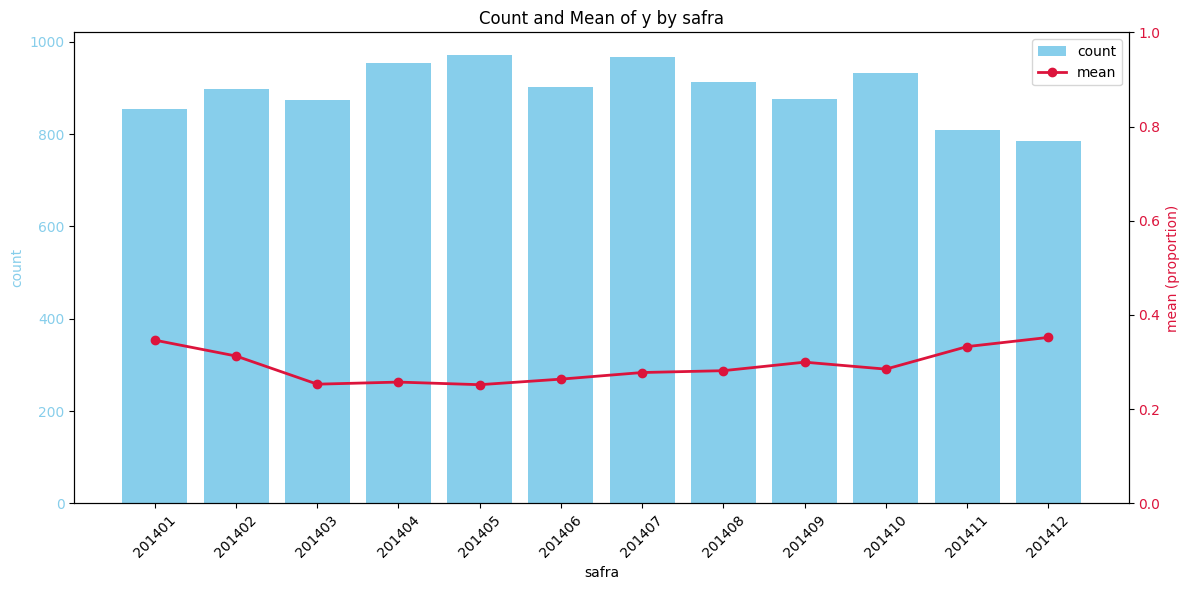

In [5]:
aux = df.groupby(['safra'])['y'].agg(['count', 'mean'])
fig, ax1 = plt.subplots(figsize=(12, 6))
aux_sorted = aux.sort_index()

ax1.bar(aux_sorted.index.astype(str), aux_sorted['count'], color='skyblue', label='count')
ax1.set_xlabel('safra')
ax1.set_ylabel('count', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(aux_sorted.index.astype(str), aux_sorted['mean'], color='crimson', marker='o', linewidth=2, label='mean')
ax2.set_ylabel('mean (proportion)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 1)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Count and Mean of y by safra')
plt.tight_layout()
plt.show()

Avaliando as estatísticas descritivas das variáveis numéricas, nota-se que um elevado número de variáveis possuem valores nulos e algumas delas possuem alta correlação com o target

In [6]:
def quick_summary(df, target='y'):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'missing_pct': df.isna().mean() * 100,
        'n_unique': df.nunique(),
        'mean': df.mean(numeric_only=True),
        'std': df.std(numeric_only=True),
        'min': df.min(numeric_only=True),
        'p25': df.quantile(0.25, numeric_only=True),
        'p50': df.quantile(0.50, numeric_only=True),
        'p75': df.quantile(0.75, numeric_only=True),
        'max': df.max(numeric_only=True)
    })

    # Correlação com o alvo (para numéricas)
    if target in df.columns:
        summary['corr_y'] = df.corr(numeric_only=True)[target]
    
    return summary

summary = quick_summary(df)
summary.head(100)


,dtype,missing_pct,n_unique,mean,std,min,p25,p50,p75,max,corr_y
VAR_1,float64,3.874092,196,32.999225,46.367685,0.00,0.000,16.000,46.0000,208.00,0.336045
VAR_10,float64,51.825293,1256,459.671564,379.460078,3.00,206.000,363.000,594.0000,3414.00,-0.015858
VAR_11,float64,46.414602,3813,69.301493,62.657513,0.01,30.545,52.745,88.4425,1652.94,0.005063
VAR_12,float64,67.023654,1112,457.369105,390.039932,5.00,198.000,354.000,592.0000,4284.00,-0.025202
VAR_13,float64,48.593779,4283,89.957121,77.141434,0.99,40.230,68.270,114.6200,1059.56,-0.014363
...,...,...,...,...,...,...,...,...,...,...,...
VAR_8,float64,45.008381,3963,71.023892,70.204828,0.98,31.410,54.980,89.9800,2891.73,0.032980
VAR_9,float64,0.000000,2023,1156.501271,663.644517,150.00,650.000,1000.000,1500.0000,3000.00,0.115453
id,int64,0.000000,10738,5369.500000,3099.937929,1.00,2685.250,5369.500,8053.7500,10738.00,-0.002748
safra,int64,0.000000,12,201406.423543,3.376001,201401.00,201404.000,201406.000,201409.0000,201412.00,0.019074


A função abaixo categoriza as variáveis explicativas numéricas e calculas os valores de Weight of Evidence para os níveis e o Information Value da Variável com relação a target.
O Information Value dessas variáveis discretizadas será usado posteriormente para critério de seleção de variáveis

In [7]:
# -----------------------------------------
# Função para calcular WOE e IV por bins
# -----------------------------------------
def compute_woe_iv(series, target, bins=10):
    df_temp = pd.DataFrame({"x": series, "y": target})

    # grupo de missing
    df_missing = df_temp[df_temp["x"].isna()].copy()
    df_not_missing = df_temp[df_temp["x"].notna()].copy()

    # binning apenas nos não-missing
    if df_not_missing["x"].nunique() > 1:
        df_not_missing["bin"] = pd.qcut(df_not_missing["x"], q=bins, duplicates="drop")
    else:
        # caso especial: variável constante nos não-missing
        df_not_missing["bin"] = "BIN_UNICO"

    # grupo missing recebe bin separado
    df_missing["bin"] = "MISSING"

    # junta novamente
    df_binned = pd.concat([df_not_missing, df_missing], ignore_index=True)

    # agrupa
    grouped = df_binned.groupby("bin")

    woe_table = pd.DataFrame({
        "count": grouped.size(),
        "event": grouped["y"].sum(),
        "non_event": grouped["y"].count() - grouped["y"].sum()
    })

    # evitar divisão por zero
    woe_table["dist_event"] = woe_table["event"] / woe_table["event"].sum()
    woe_table["dist_non_event"] = woe_table["non_event"] / woe_table["non_event"].sum()

    woe_table["WOE"] = np.log(
        (woe_table["dist_event"] + 1e-6) /
        (woe_table["dist_non_event"] + 1e-6)
    )

    woe_table["IV"] = (woe_table["dist_event"] - woe_table["dist_non_event"]) * woe_table["WOE"]

    total_iv = woe_table["IV"].sum()

    return woe_table, total_iv


# -----------------------------------------
# Função 2 — análise numérica completa
# -----------------------------------------
def analyze_numeric_variable(df, var, target="y", bins=10):
    print(f"\n===============================")
    print(f"Analisando variável: {var}")
    print(f"===============================\n")

    # -------- BOXLOT por target --------
    plt.figure(figsize=(6,4))
    df.boxplot(column=var, by=target)
    plt.title(f"Boxplot de {var} por {target}")
    plt.suptitle("")
    plt.xlabel(target)
    plt.ylabel(var)
    plt.show()

    # -------- WOE/IV --------
    woe_table, iv = compute_woe_iv(df[var], df[target], bins=bins)
    print("Tabela de WOE/IV:")
    print(f"\nIV total: {iv:.4f}")

    return woe_table, iv


Analisando variável: VAR_1



<Figure size 600x400 with 0 Axes>

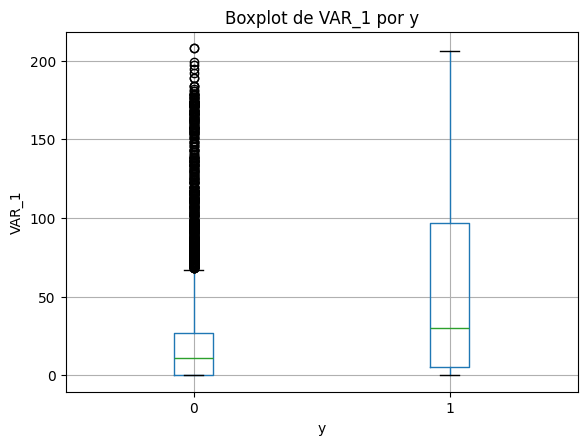

Tabela de WOE/IV:

IV total: 0.4681

Analisando variável: VAR_2



<Figure size 600x400 with 0 Axes>

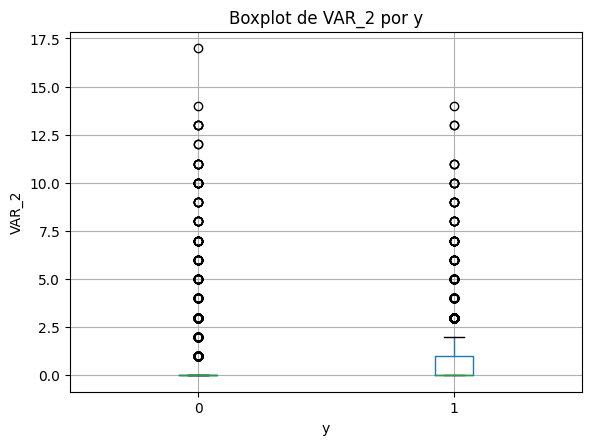

Tabela de WOE/IV:

IV total: 0.3386

Analisando variável: VAR_3



<Figure size 600x400 with 0 Axes>

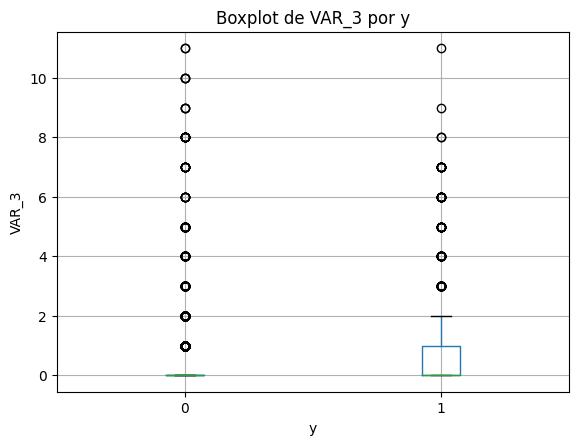

Tabela de WOE/IV:

IV total: 0.0270

Analisando variável: VAR_4



<Figure size 600x400 with 0 Axes>

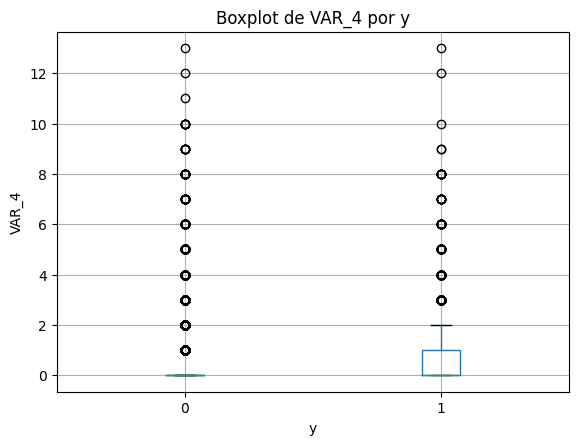

Tabela de WOE/IV:

IV total: 0.0597

Analisando variável: VAR_5



<Figure size 600x400 with 0 Axes>

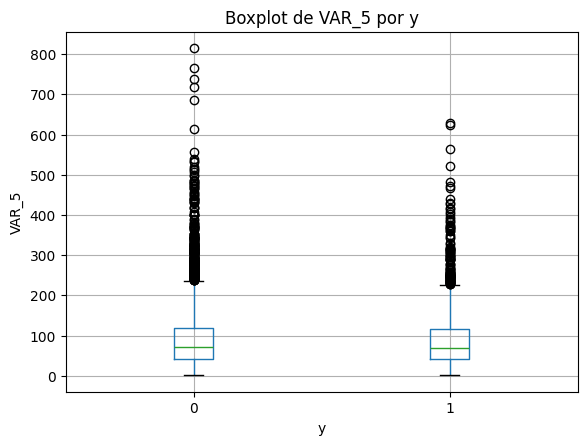

Tabela de WOE/IV:

IV total: 0.0201

Analisando variável: VAR_6



<Figure size 600x400 with 0 Axes>

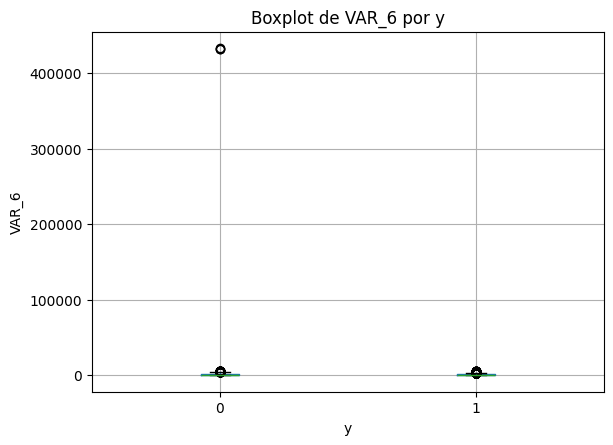

Tabela de WOE/IV:

IV total: 0.1731

Analisando variável: VAR_7



<Figure size 600x400 with 0 Axes>

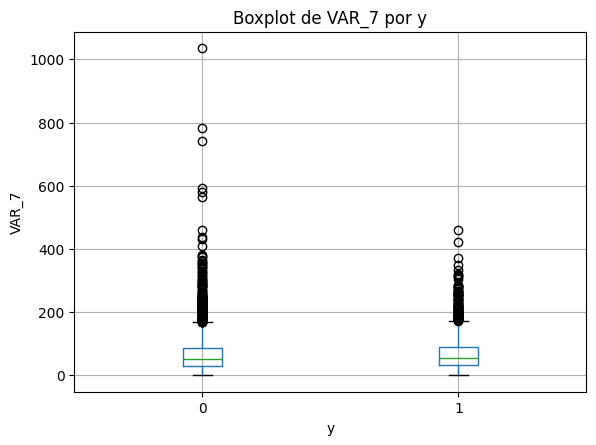

Tabela de WOE/IV:

IV total: 0.0143

Analisando variável: VAR_8



<Figure size 600x400 with 0 Axes>

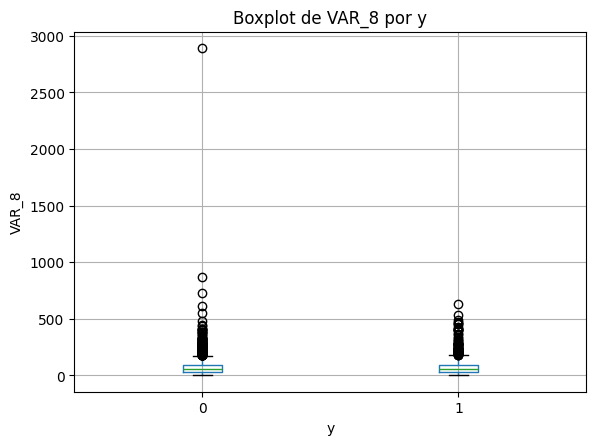

Tabela de WOE/IV:

IV total: 0.0144

Analisando variável: VAR_9



<Figure size 600x400 with 0 Axes>

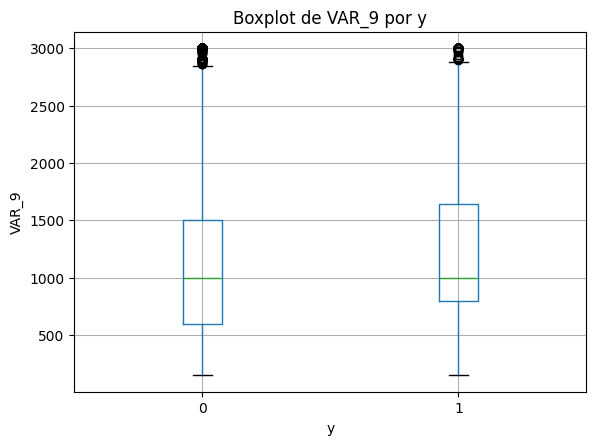

Tabela de WOE/IV:

IV total: 0.1017

Analisando variável: VAR_10



<Figure size 600x400 with 0 Axes>

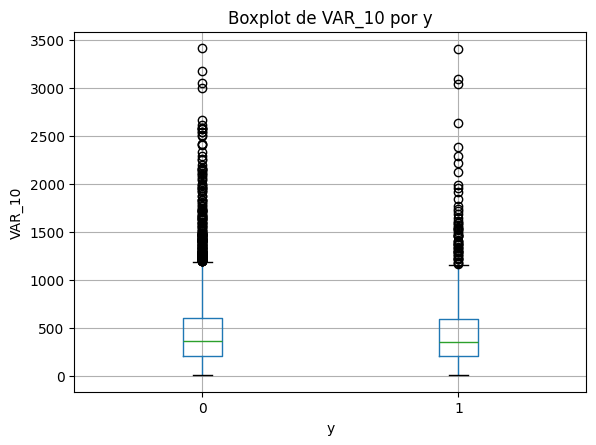

Tabela de WOE/IV:

IV total: 0.0958

Analisando variável: VAR_11



<Figure size 600x400 with 0 Axes>

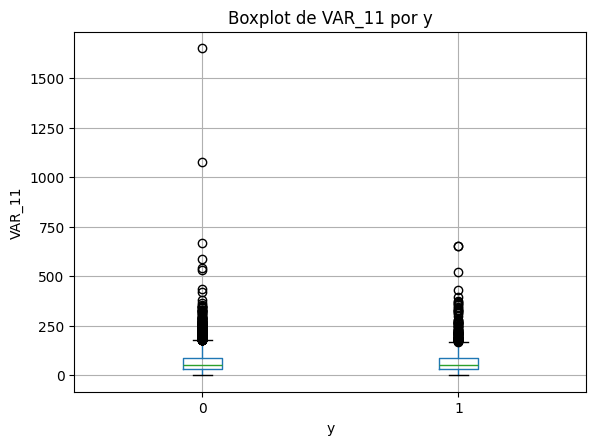

Tabela de WOE/IV:

IV total: 0.0067

Analisando variável: VAR_12



<Figure size 600x400 with 0 Axes>

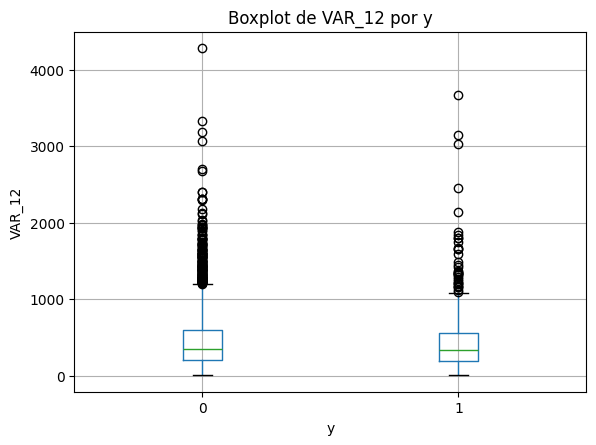

Tabela de WOE/IV:

IV total: 0.1065

Analisando variável: VAR_13



<Figure size 600x400 with 0 Axes>

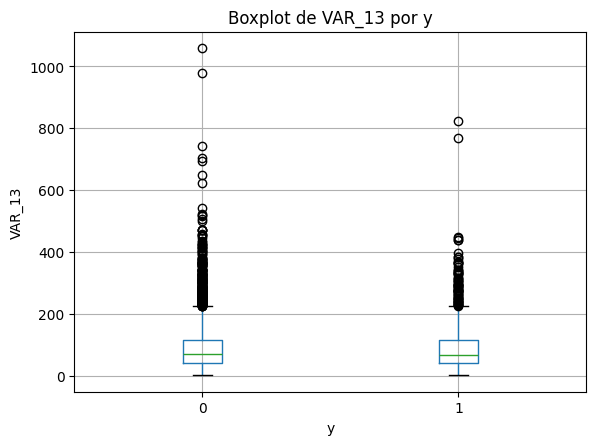

Tabela de WOE/IV:

IV total: 0.0390

Analisando variável: VAR_14



<Figure size 600x400 with 0 Axes>

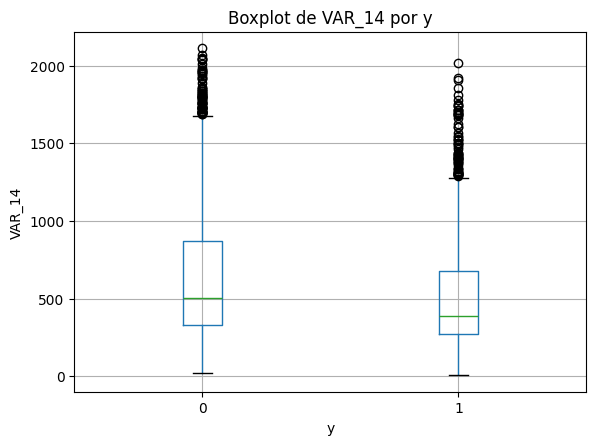

Tabela de WOE/IV:

IV total: 0.0809

Analisando variável: VAR_15



<Figure size 600x400 with 0 Axes>

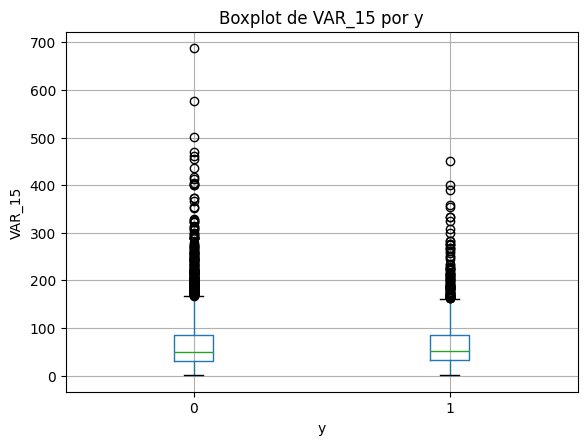

Tabela de WOE/IV:

IV total: 0.0074

Analisando variável: VAR_16



<Figure size 600x400 with 0 Axes>

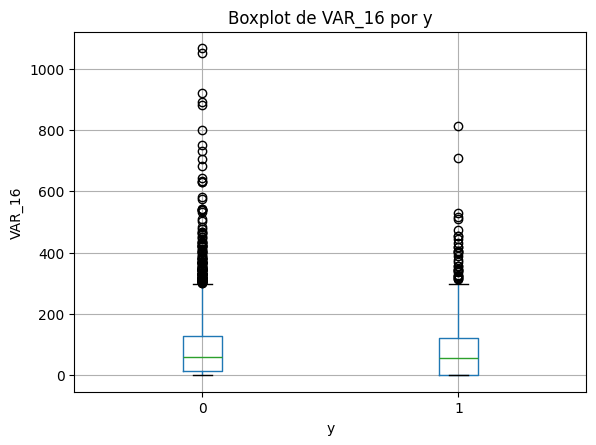

Tabela de WOE/IV:

IV total: 0.1396

Analisando variável: VAR_17



<Figure size 600x400 with 0 Axes>

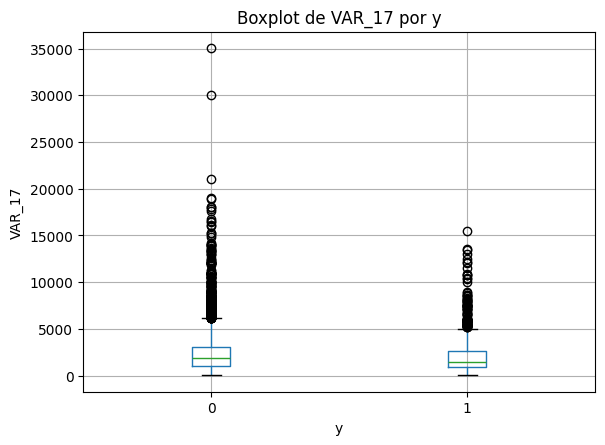

Tabela de WOE/IV:

IV total: 0.1058

Analisando variável: VAR_18



<Figure size 600x400 with 0 Axes>

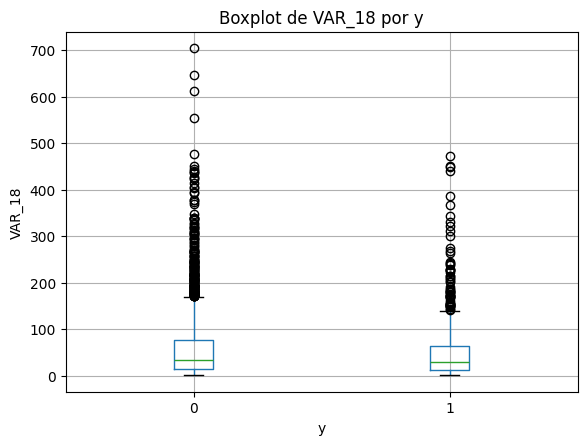

Tabela de WOE/IV:

IV total: 0.1355

Analisando variável: VAR_19



<Figure size 600x400 with 0 Axes>

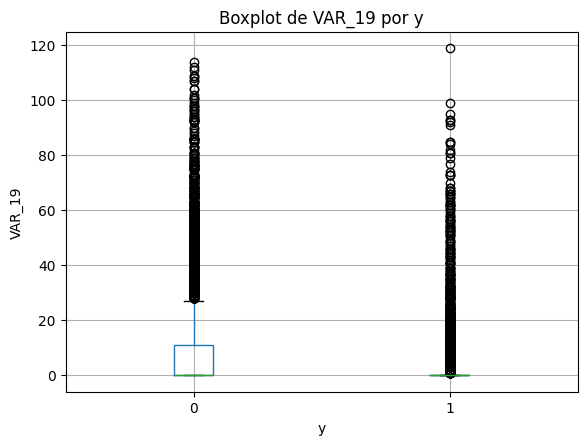

Tabela de WOE/IV:

IV total: 0.1230

Analisando variável: VAR_20



<Figure size 600x400 with 0 Axes>

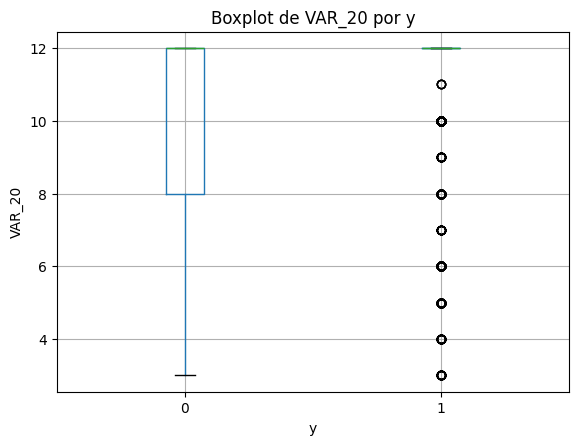

Tabela de WOE/IV:

IV total: 0.1584

Analisando variável: VAR_21



<Figure size 600x400 with 0 Axes>

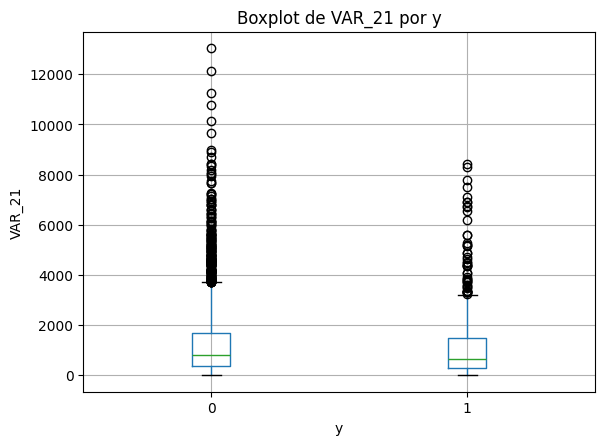

Tabela de WOE/IV:

IV total: 0.1368

Analisando variável: VAR_22



<Figure size 600x400 with 0 Axes>

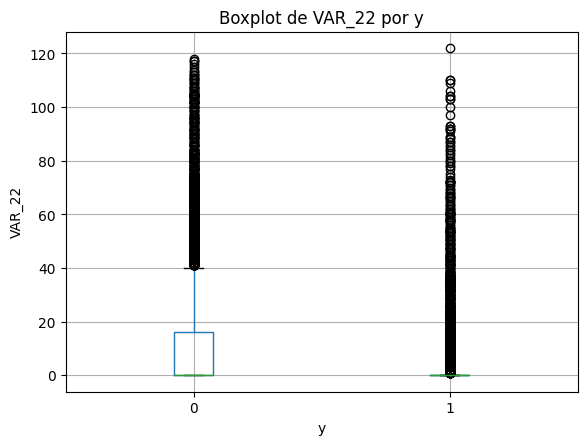

Tabela de WOE/IV:

IV total: 0.1107

Analisando variável: VAR_23



<Figure size 600x400 with 0 Axes>

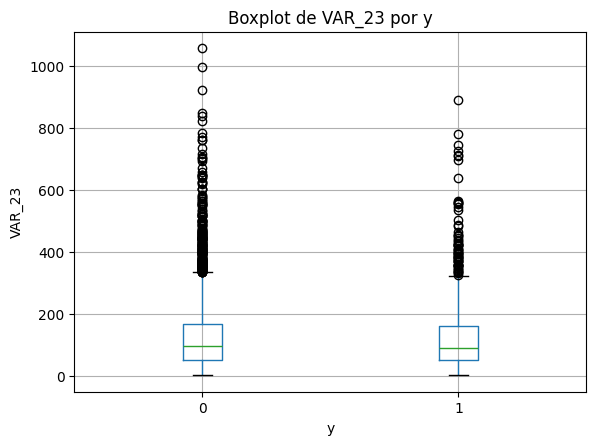

Tabela de WOE/IV:

IV total: 0.0939

Analisando variável: VAR_24



<Figure size 600x400 with 0 Axes>

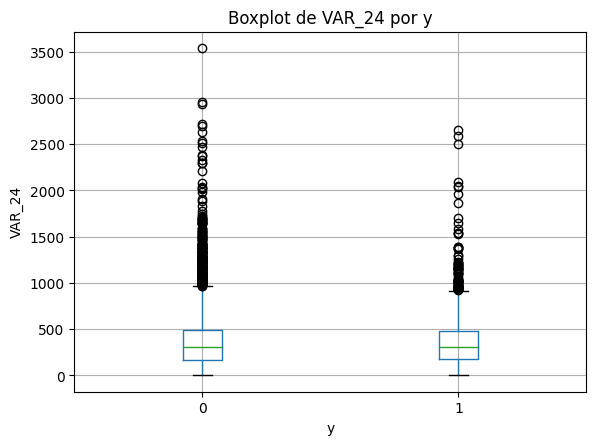

Tabela de WOE/IV:

IV total: 0.0230

Analisando variável: VAR_25



<Figure size 600x400 with 0 Axes>

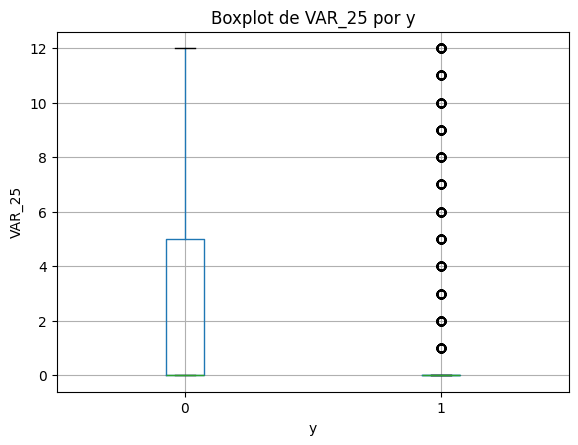

Tabela de WOE/IV:

IV total: 0.1201

Analisando variável: VAR_26



<Figure size 600x400 with 0 Axes>

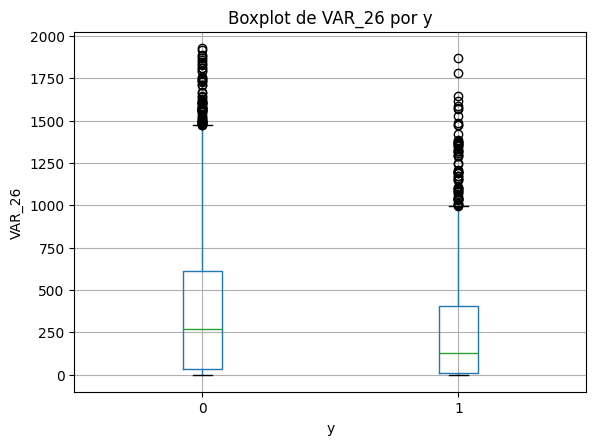

Tabela de WOE/IV:

IV total: 0.0866

Analisando variável: VAR_27



<Figure size 600x400 with 0 Axes>

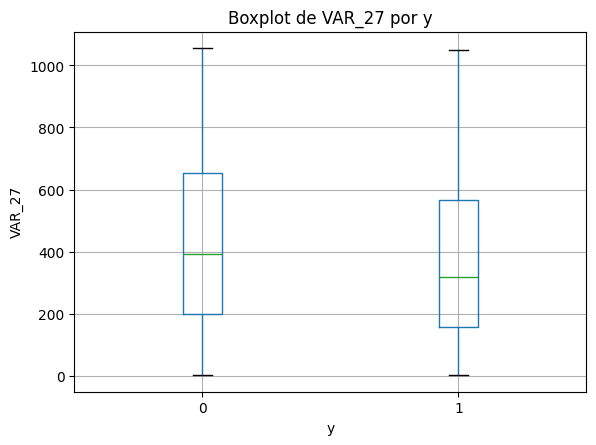

Tabela de WOE/IV:

IV total: 0.0505

Analisando variável: VAR_28



<Figure size 600x400 with 0 Axes>

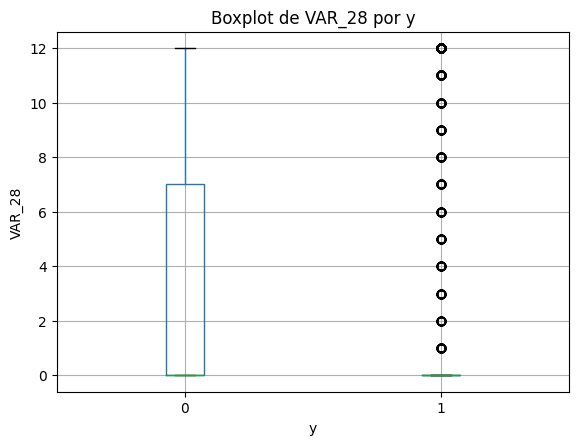

Tabela de WOE/IV:

IV total: 0.1121

Analisando variável: VAR_29



<Figure size 600x400 with 0 Axes>

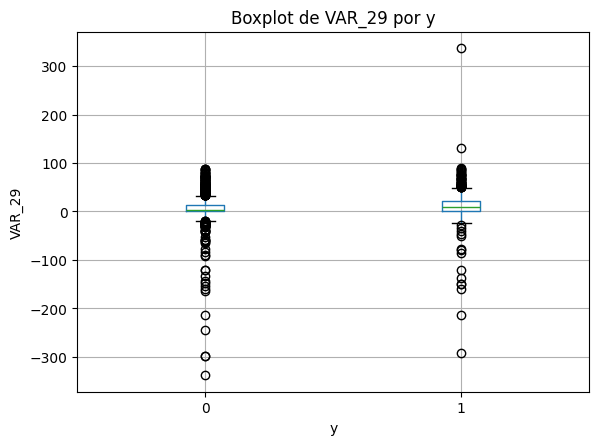

Tabela de WOE/IV:

IV total: 0.1077

Analisando variável: VAR_30



<Figure size 600x400 with 0 Axes>

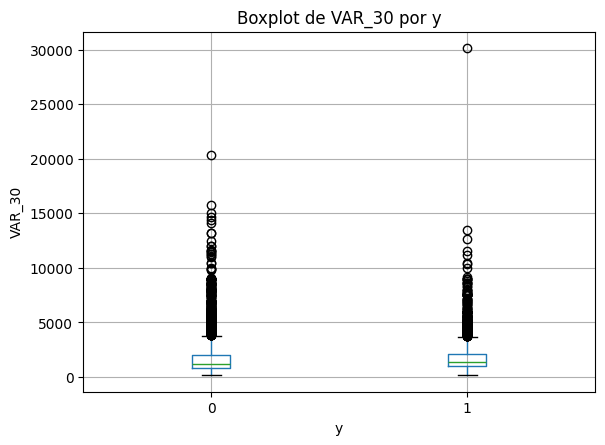

Tabela de WOE/IV:

IV total: 0.0531

Analisando variável: VAR_31



<Figure size 600x400 with 0 Axes>

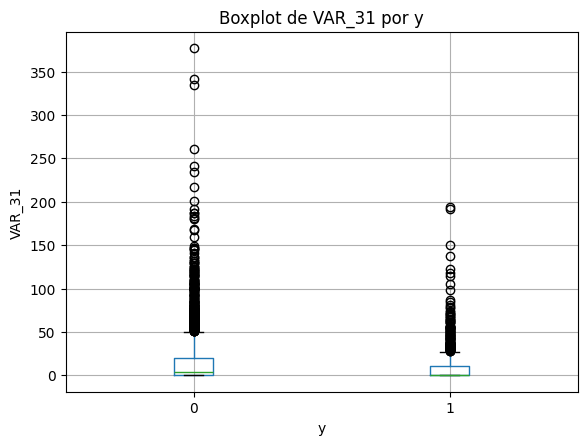

Tabela de WOE/IV:

IV total: 0.1262

Analisando variável: VAR_33



<Figure size 600x400 with 0 Axes>

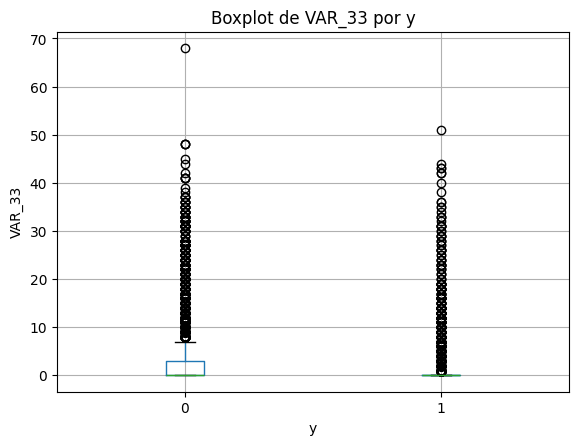

Tabela de WOE/IV:

IV total: 0.0889

Analisando variável: VAR_34



<Figure size 600x400 with 0 Axes>

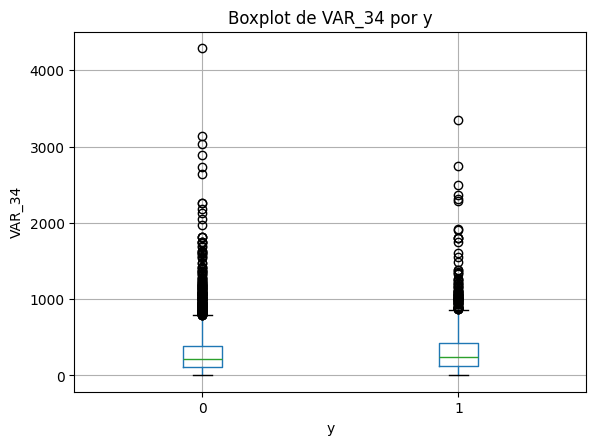

Tabela de WOE/IV:

IV total: 0.0208

Analisando variável: VAR_35



<Figure size 600x400 with 0 Axes>

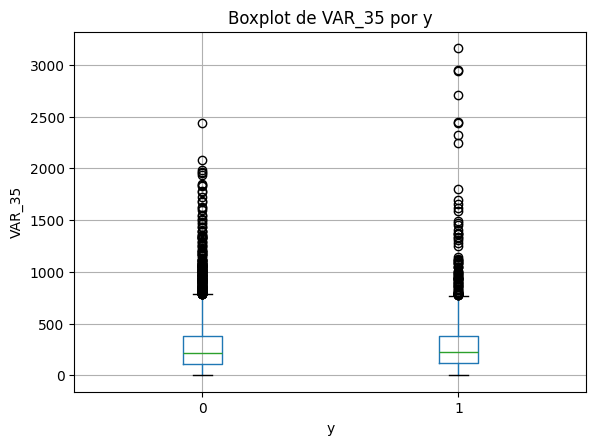

Tabela de WOE/IV:

IV total: 0.0087

Analisando variável: VAR_36



<Figure size 600x400 with 0 Axes>

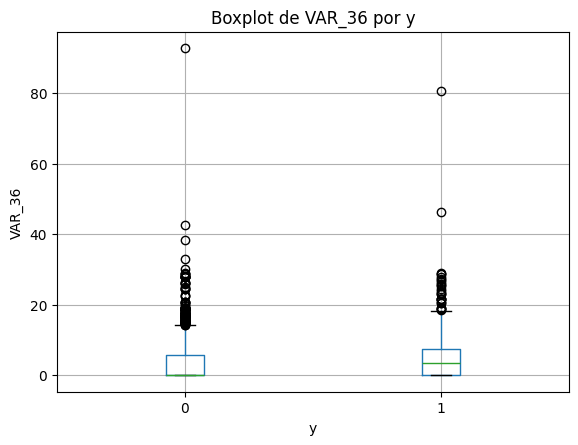

Tabela de WOE/IV:

IV total: 0.0530

Analisando variável: VAR_37



<Figure size 600x400 with 0 Axes>

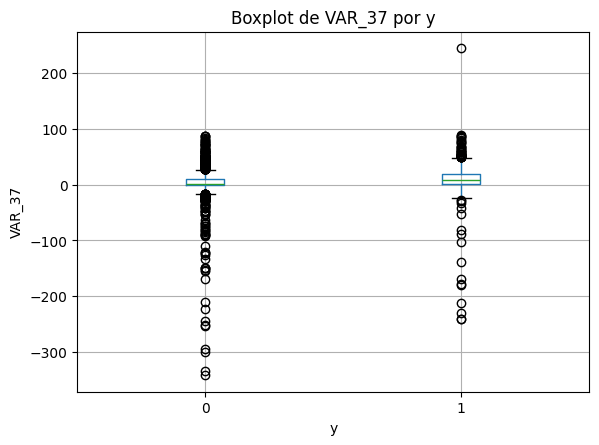

Tabela de WOE/IV:

IV total: 0.1125

Analisando variável: VAR_38



<Figure size 600x400 with 0 Axes>

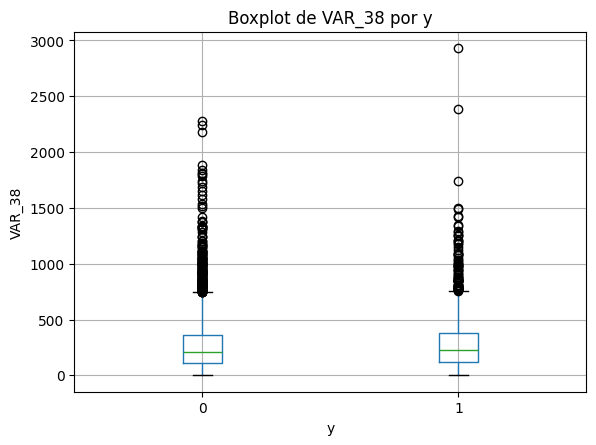

Tabela de WOE/IV:

IV total: 0.0175

Analisando variável: VAR_39



<Figure size 600x400 with 0 Axes>

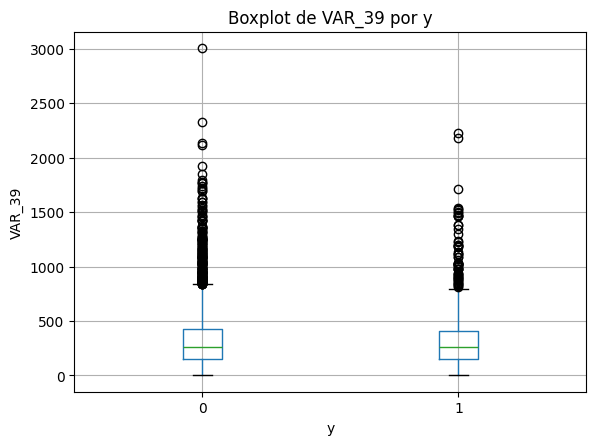

Tabela de WOE/IV:

IV total: 0.0410

Analisando variável: VAR_40



<Figure size 600x400 with 0 Axes>

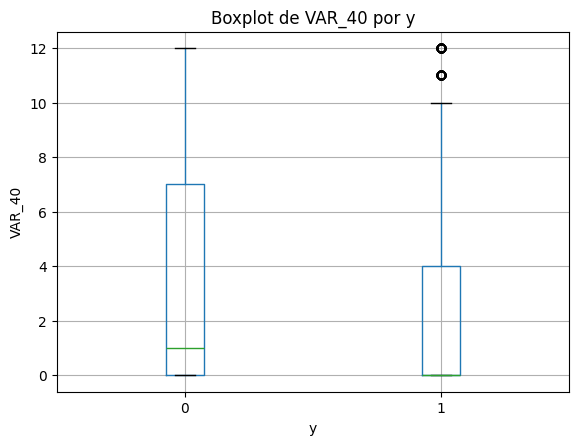

Tabela de WOE/IV:

IV total: 0.1012

Analisando variável: VAR_41



<Figure size 600x400 with 0 Axes>

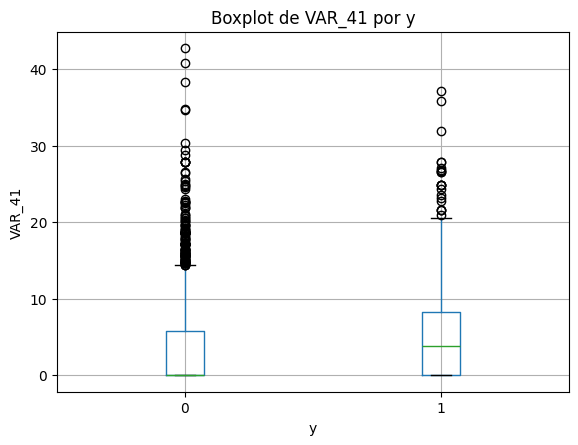

Tabela de WOE/IV:

IV total: 0.0615

Analisando variável: VAR_42



<Figure size 600x400 with 0 Axes>

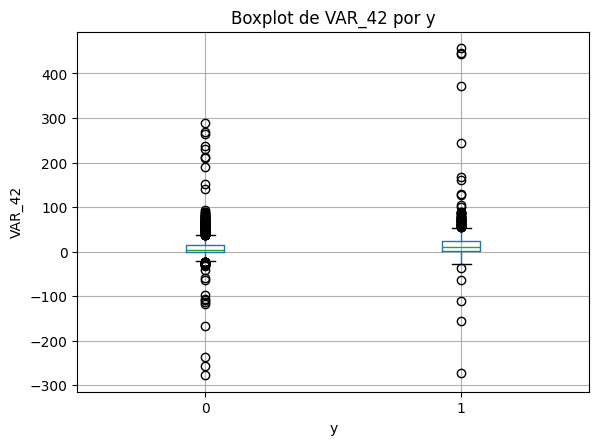

Tabela de WOE/IV:

IV total: 0.1039

Analisando variável: VAR_43



<Figure size 600x400 with 0 Axes>

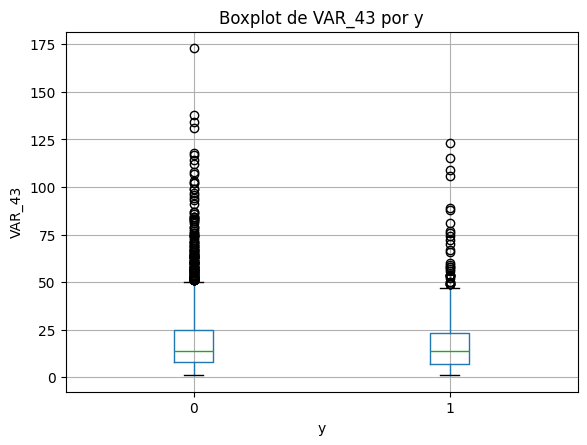

Tabela de WOE/IV:

IV total: 0.1111

Analisando variável: VAR_44



<Figure size 600x400 with 0 Axes>

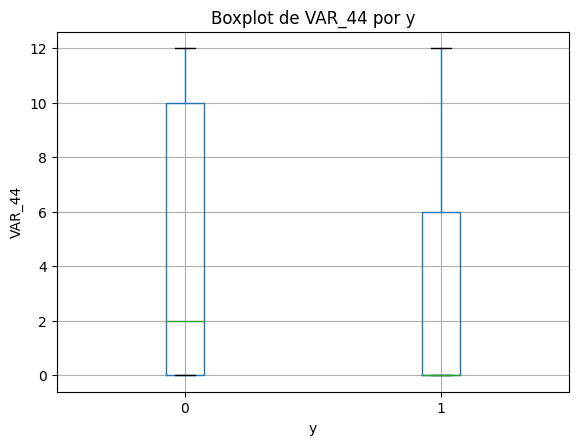

Tabela de WOE/IV:

IV total: 0.1068

Analisando variável: VAR_45



<Figure size 600x400 with 0 Axes>

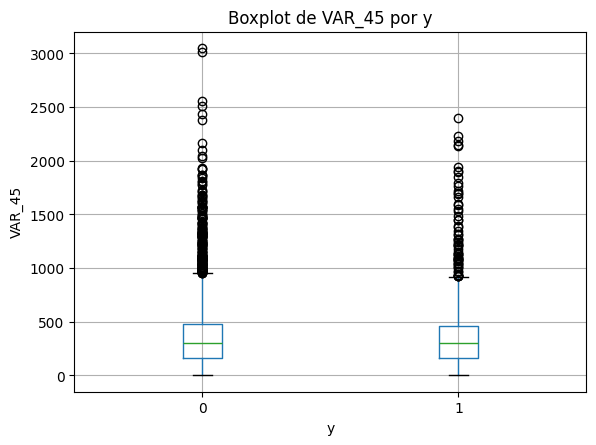

Tabela de WOE/IV:

IV total: 0.0447

Analisando variável: VAR_46



<Figure size 600x400 with 0 Axes>

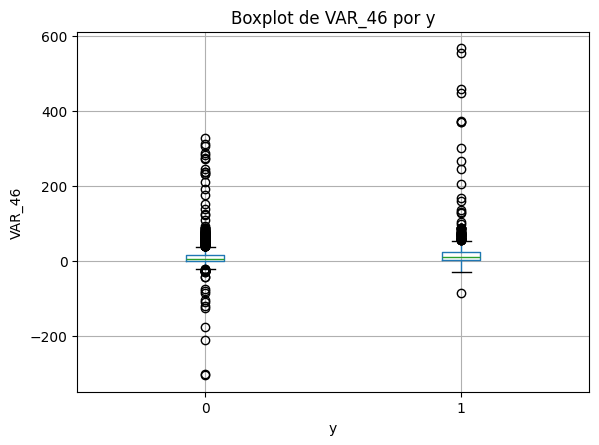

Tabela de WOE/IV:

IV total: 0.1042

Analisando variável: VAR_47



<Figure size 600x400 with 0 Axes>

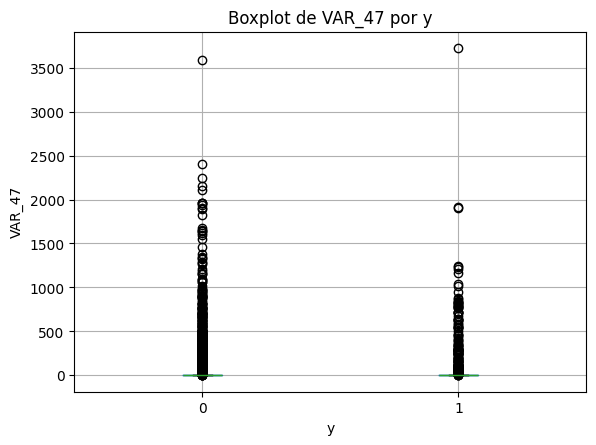

Tabela de WOE/IV:

IV total: 0.1345

Analisando variável: VAR_48



<Figure size 600x400 with 0 Axes>

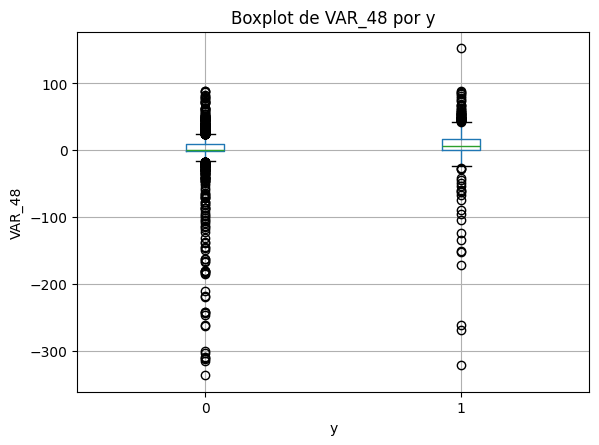

Tabela de WOE/IV:

IV total: 0.1023

Analisando variável: VAR_49



<Figure size 600x400 with 0 Axes>

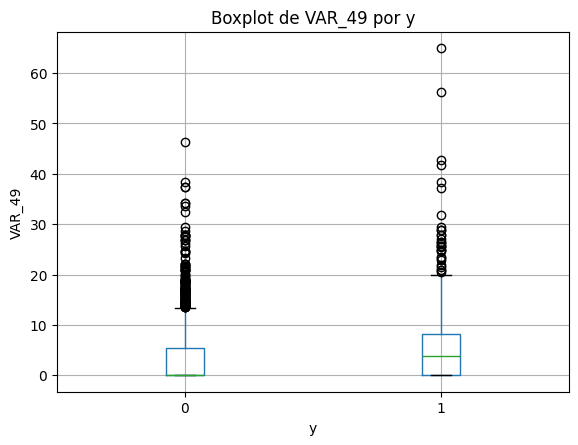

Tabela de WOE/IV:

IV total: 0.0503

Analisando variável: VAR_51



<Figure size 600x400 with 0 Axes>

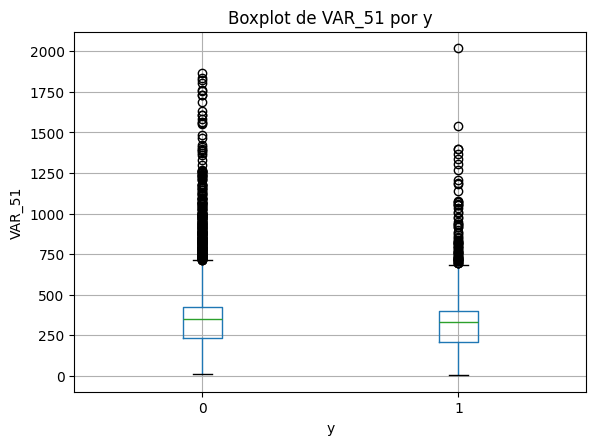

Tabela de WOE/IV:

IV total: 0.0488

Analisando variável: VAR_52



<Figure size 600x400 with 0 Axes>

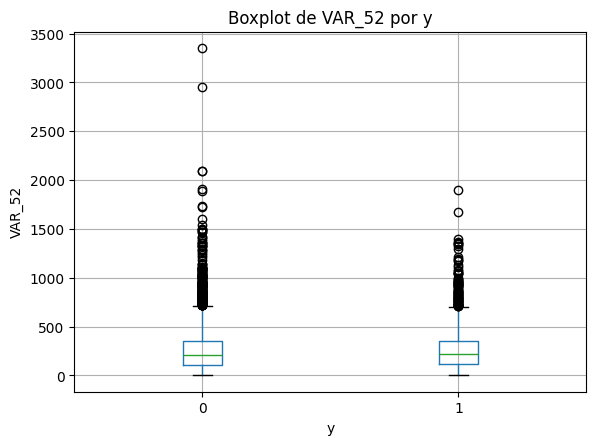

Tabela de WOE/IV:

IV total: 0.0088

Analisando variável: VAR_53



<Figure size 600x400 with 0 Axes>

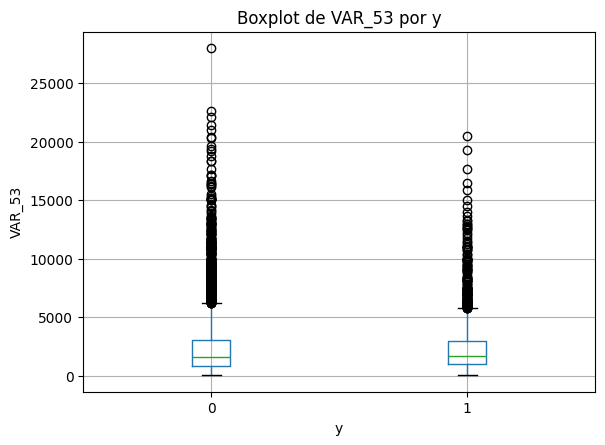

Tabela de WOE/IV:

IV total: 0.0518

Analisando variável: VAR_54



<Figure size 600x400 with 0 Axes>

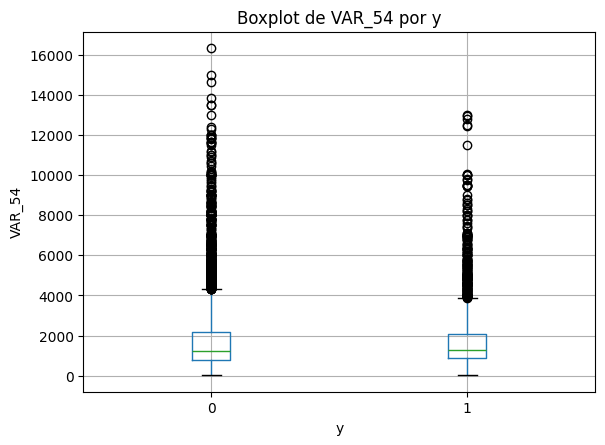

Tabela de WOE/IV:

IV total: 0.0467

Analisando variável: VAR_57



<Figure size 600x400 with 0 Axes>

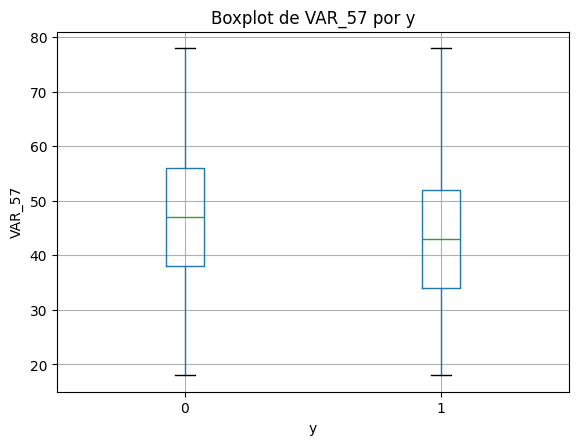

Tabela de WOE/IV:

IV total: 0.0923

Analisando variável: VAR_58



<Figure size 600x400 with 0 Axes>

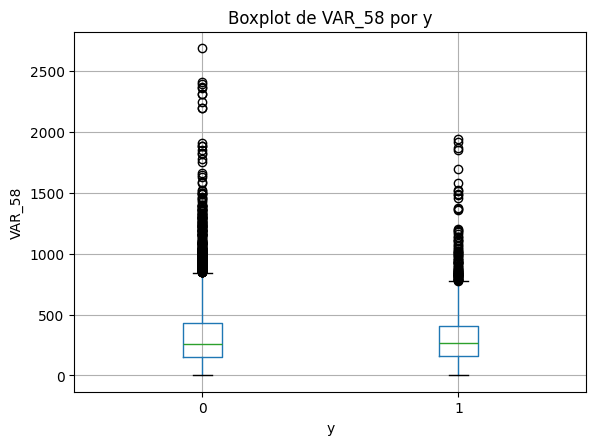

Tabela de WOE/IV:

IV total: 0.0241

Analisando variável: VAR_59



<Figure size 600x400 with 0 Axes>

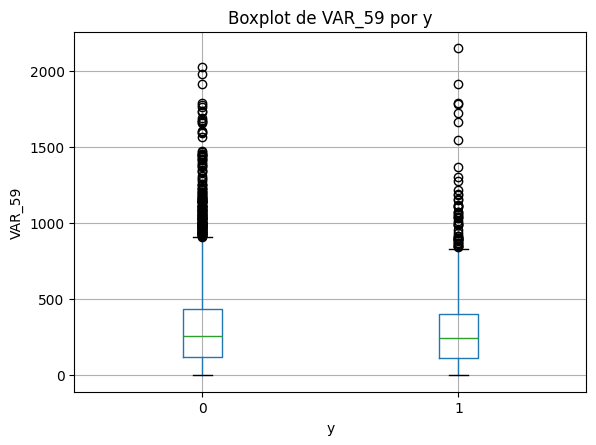

Tabela de WOE/IV:

IV total: 0.0651

Analisando variável: VAR_61



<Figure size 600x400 with 0 Axes>

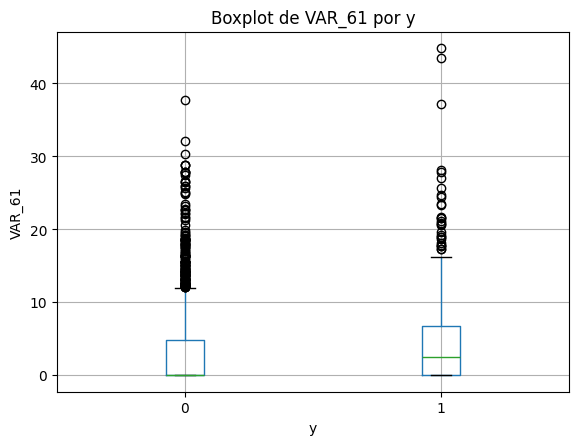

Tabela de WOE/IV:

IV total: 0.0466

Analisando variável: VAR_62



<Figure size 600x400 with 0 Axes>

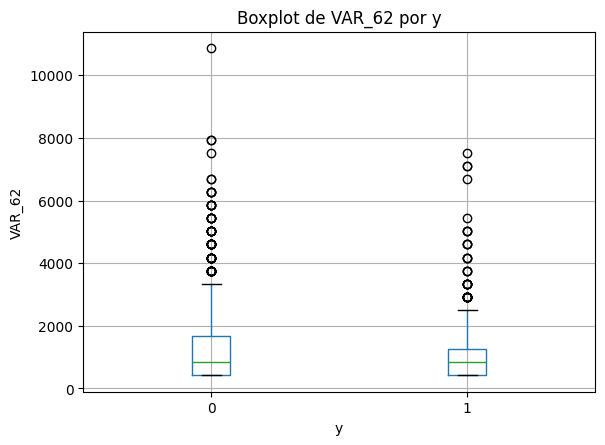

Tabela de WOE/IV:

IV total: 0.1047

Analisando variável: VAR_64



<Figure size 600x400 with 0 Axes>

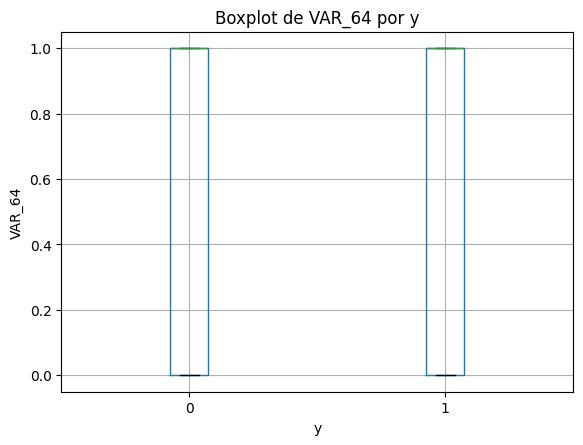

Tabela de WOE/IV:

IV total: 0.0000

Analisando variável: VAR_65



<Figure size 600x400 with 0 Axes>

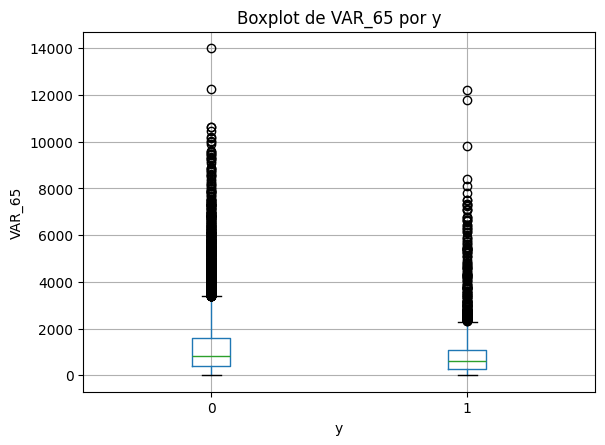

Tabela de WOE/IV:

IV total: 0.1188

Analisando variável: VAR_66



<Figure size 600x400 with 0 Axes>

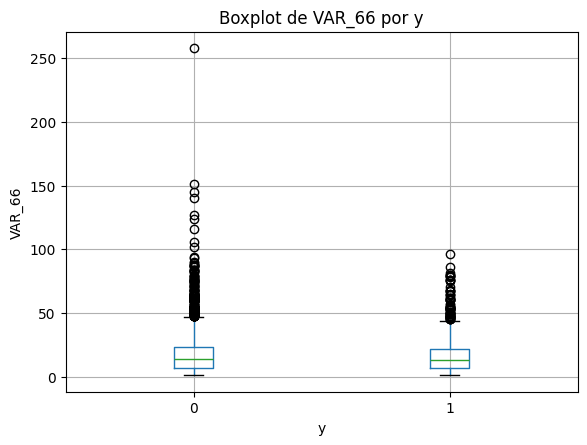

Tabela de WOE/IV:

IV total: 0.0948

Analisando variável: VAR_67



<Figure size 600x400 with 0 Axes>

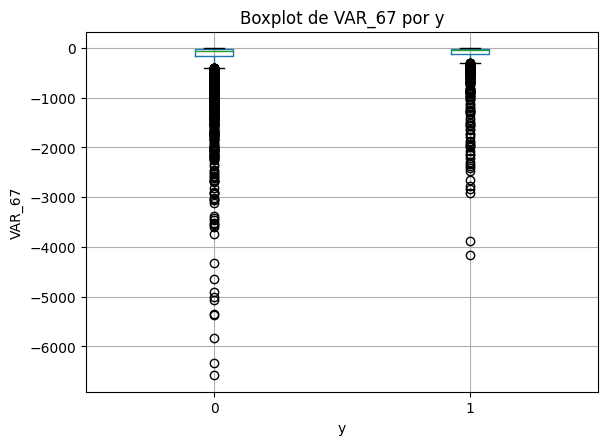

Tabela de WOE/IV:

IV total: 0.0649

Analisando variável: VAR_68



<Figure size 600x400 with 0 Axes>

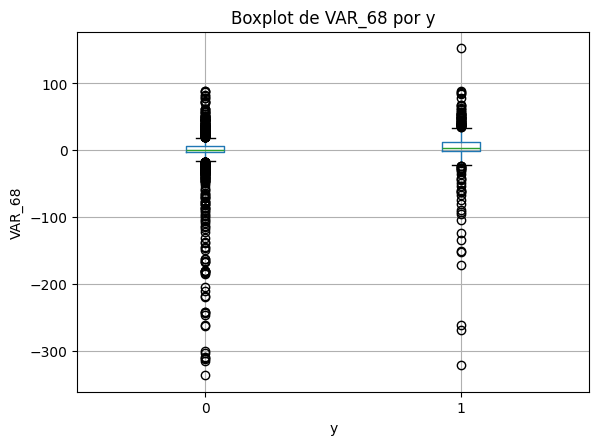

Tabela de WOE/IV:

IV total: 0.0803

Analisando variável: VAR_69



<Figure size 600x400 with 0 Axes>

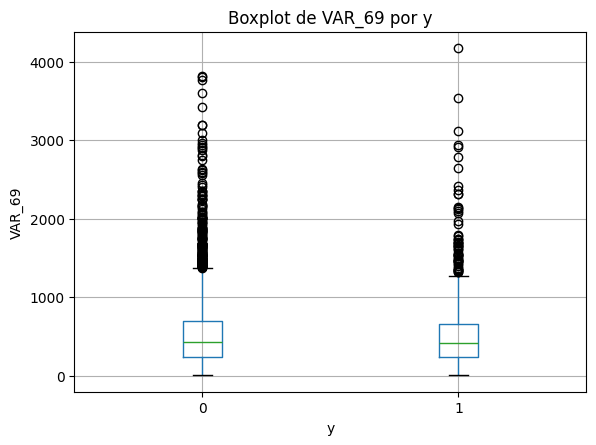

Tabela de WOE/IV:

IV total: 0.0992

Analisando variável: VAR_70



<Figure size 600x400 with 0 Axes>

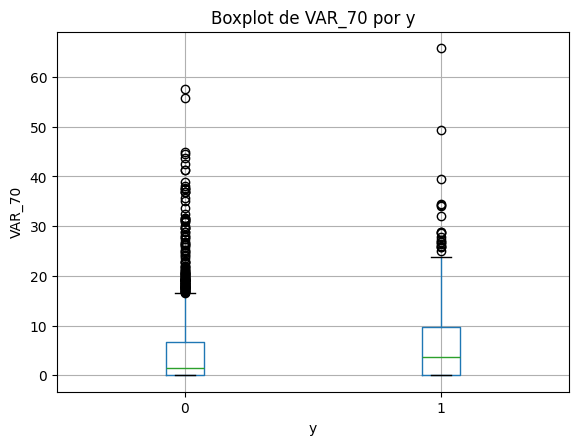

Tabela de WOE/IV:

IV total: 0.0659

Analisando variável: VAR_71



<Figure size 600x400 with 0 Axes>

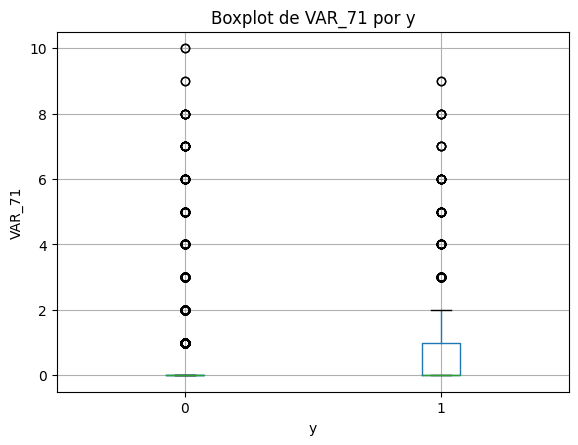

Tabela de WOE/IV:

IV total: 0.0639

Analisando variável: VAR_72



<Figure size 600x400 with 0 Axes>

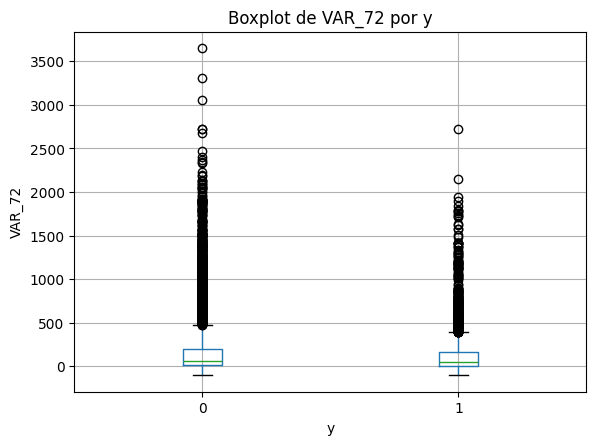

Tabela de WOE/IV:

IV total: 0.0240

Analisando variável: VAR_73



<Figure size 600x400 with 0 Axes>

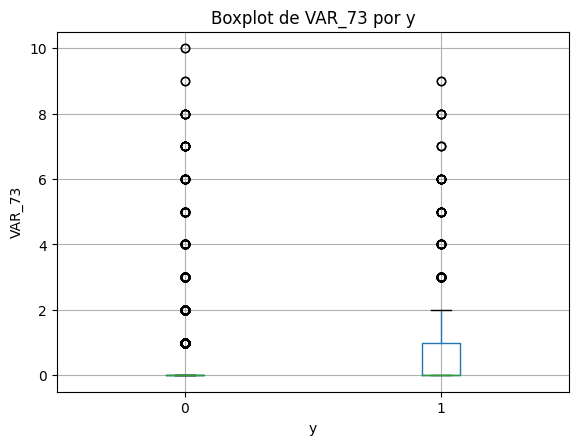

Tabela de WOE/IV:

IV total: 0.0631

Analisando variável: VAR_74



<Figure size 600x400 with 0 Axes>

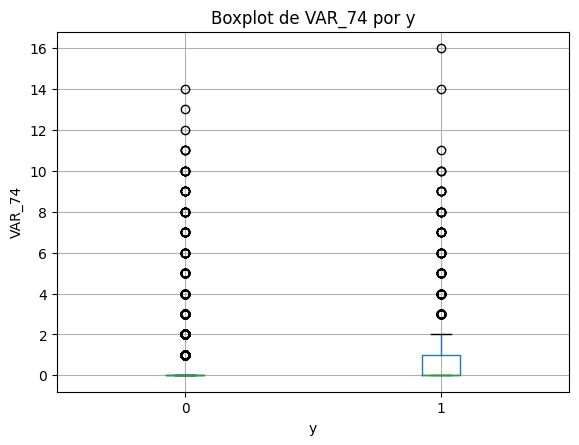

Tabela de WOE/IV:

IV total: 0.0655

Analisando variável: VAR_75



<Figure size 600x400 with 0 Axes>

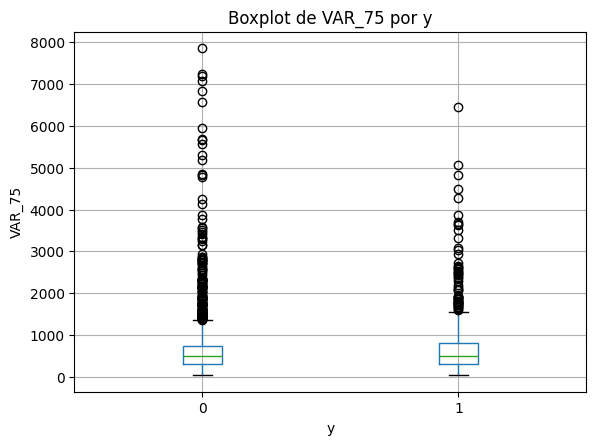

Tabela de WOE/IV:

IV total: 0.0266

Analisando variável: VAR_76



<Figure size 600x400 with 0 Axes>

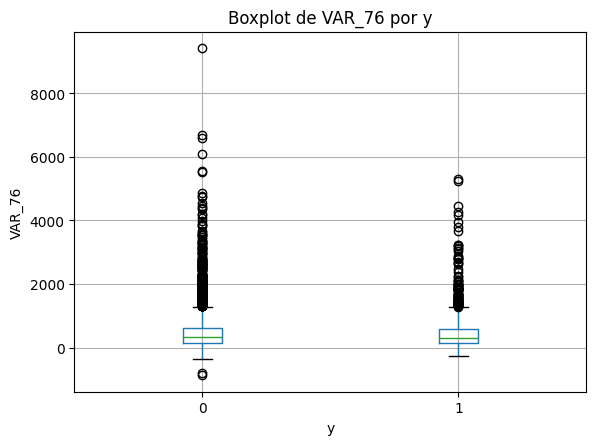

Tabela de WOE/IV:

IV total: 0.0608

Analisando variável: VAR_77



<Figure size 600x400 with 0 Axes>

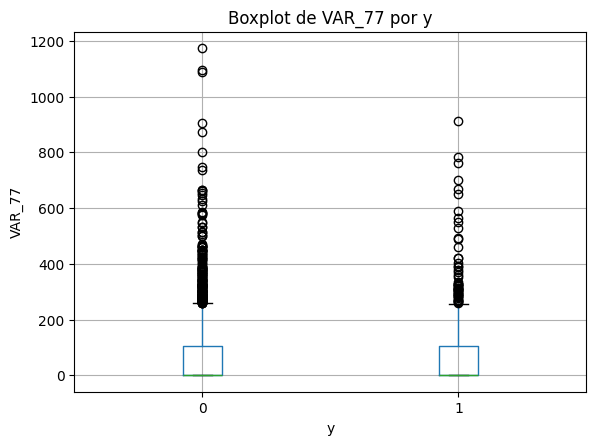

Tabela de WOE/IV:

IV total: 0.0923

Analisando variável: VAR_78



<Figure size 600x400 with 0 Axes>

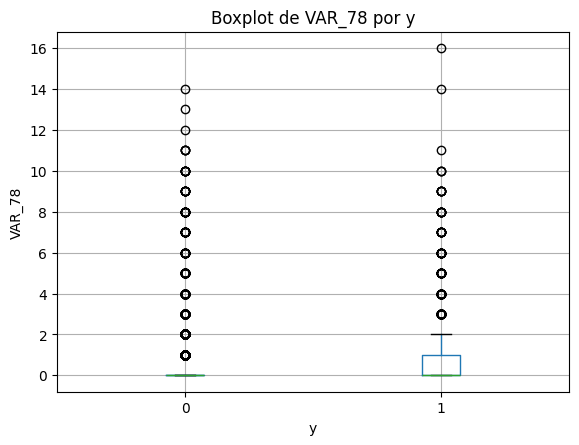

Tabela de WOE/IV:

IV total: 0.0657

=== Ranking final de IV das variáveis numéricas ===
   variable        IV
0     VAR_1  0.468131
1     VAR_2  0.338605
5     VAR_6  0.173087
19   VAR_20  0.158431
15   VAR_16  0.139557
..      ...       ...
49   VAR_52  0.008840
33   VAR_35  0.008750
14   VAR_15  0.007397
10   VAR_11  0.006709
57   VAR_64  0.000000

[72 rows x 2 columns]


In [8]:
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_vars = [v for v in numeric_vars if v != "y" and v not in ('id', 'safra')]

iv_summary = {}

for var in numeric_vars:
    try:
        woe_table, iv = analyze_numeric_variable(df, var, target="y", bins=10)
        iv_summary[var] = iv
    except Exception as e:
        print(f"Erro ao processar {var}: {e}")

iv_rank = (
    pd.DataFrame({"variable": iv_summary.keys(), "IV": iv_summary.values()})
    .sort_values("IV", ascending=False)
)

print("\n=== Ranking final de IV das variáveis numéricas ===")
print(iv_rank)

Filtra-se inicialmente as variáveis com IV maior que 0.05 (que possuem alguma interação relevante com a variável target)

In [9]:
# seleciona variáveis fora do filtro de baixo IV (ou seja, IV > 0.05)
iv_vars = iv_rank.loc[iv_rank.IV >= 0.05, 'variable'].to_list()

# mantém apenas as colunas que existem no df (evita KeyError) e adiciona id/safra/y
selected_cols = [c for c  in iv_vars if c in df.columns]
selected_cols = ['id', 'safra', 'y'] + selected_cols

# cria o dataframe filtrado
df_filter_iv = df[selected_cols].copy()

# mostra resumo rápido
df_filter_iv.head()

,id,safra,y,VAR_1,VAR_2,VAR_6,VAR_20,VAR_16,VAR_21,VAR_18,...,VAR_71,VAR_73,VAR_41,VAR_76,VAR_4,VAR_30,VAR_36,VAR_53,VAR_27,VAR_49
0,1,201404,0,0.0,0.0,3277.0,8,162.0,1279.0,72.0,...,0.0,0.0,9.57,173.06,0.0,500.00,0.0,3380.00,NaN,0.0
1,2,201407,0,64.0,0.0,2443.0,12,84.0,1063.0,50.0,...,NaN,NaN,NaN,184.69,1.0,1000.00,NaN,1000.00,842.0,NaN
2,3,201405,0,99.0,2.0,1824.0,12,8.0,116.0,3.0,...,NaN,NaN,NaN,732.00,2.0,1893.35,NaN,1893.35,597.0,NaN
3,4,201412,0,0.0,0.0,3796.0,12,36.0,255.0,17.0,...,0.0,0.0,NaN,NaN,0.0,3000.00,0.0,3000.00,NaN,NaN
4,5,201403,1,0.0,0.0,437.0,12,NaN,NaN,NaN,...,0.0,0.0,0.00,NaN,0.0,2000.00,0.0,2946.29,NaN,0.0


Posteriormente, ooharmos os percentuais de nulos para as variáveis filtradas

In [10]:
numeric_vars = df_filter_iv.select_dtypes(include=[np.number]).columns.tolist()

missing_rate = df_filter_iv[numeric_vars].isna().mean().sort_values()
missing_rate

id        0.000000
safra     0.000000
y         0.000000
VAR_20    0.000000
VAR_9     0.000000
VAR_57    0.000000
VAR_30    0.004470
VAR_19    0.005681
VAR_22    0.005681
VAR_44    0.005681
VAR_40    0.005681
VAR_25    0.005681
VAR_28    0.005681
VAR_33    0.005681
VAR_6     0.008475
VAR_2     0.038741
VAR_4     0.038741
VAR_1     0.038741
VAR_53    0.163811
VAR_65    0.208512
VAR_17    0.419166
VAR_76    0.423822
VAR_59    0.423822
VAR_78    0.516018
VAR_26    0.516018
VAR_14    0.516018
VAR_71    0.516018
VAR_74    0.516018
VAR_73    0.516018
VAR_66    0.518253
VAR_10    0.518253
VAR_69    0.518253
VAR_23    0.518253
VAR_77    0.518253
VAR_46    0.526262
VAR_42    0.536599
VAR_31    0.543025
VAR_27    0.552617
VAR_29    0.553641
VAR_37    0.569007
VAR_67    0.572080
VAR_48    0.595269
VAR_68    0.615478
VAR_41    0.654126
VAR_47    0.661669
VAR_16    0.661855
VAR_21    0.663345
VAR_18    0.663345
VAR_43    0.670237
VAR_12    0.670237
VAR_36    0.676849
VAR_49    0.679456
VAR_70    0.

e finalmente observamos a multicolinearidade entre as variáveis 

In [11]:
corr_matrix = df_filter_iv[numeric_vars].corr().abs()
corr_matrix

threshold = 0.85
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var1", "var2", "corr"]

high_corr = corr_pairs[corr_pairs["corr"] > threshold]
high_corr

,var1,var2,corr
396,VAR_21,VAR_18,0.861975
575,VAR_19,VAR_22,0.976783
613,VAR_25,VAR_28,0.972737
877,VAR_44,VAR_40,0.968296
1064,VAR_48,VAR_68,0.957663
1131,VAR_69,VAR_10,0.976386
1156,VAR_10,VAR_23,0.884246
1278,VAR_26,VAR_14,0.957857
1340,VAR_78,VAR_74,0.998795
1343,VAR_78,VAR_71,0.868049


Por fim, fazemos a seleção das variáveis, removendo as que possuem alta correlação de Pearson e mantendo aquela com menor % de missing

In [12]:
vars_to_drop = []

for v1, v2, c in high_corr.values:
    miss_v1 = missing_rate[v1]
    miss_v2 = missing_rate[v2]

    # mantém a com menos missing
    if miss_v1 > miss_v2:
        vars_to_drop.append(v1)
    else:
        vars_to_drop.append(v2)

vars_to_drop = list(set(vars_to_drop))
vars_to_drop

['VAR_74',
 'VAR_73',
 'VAR_40',
 'VAR_14',
 'VAR_10',
 'VAR_18',
 'VAR_22',
 'VAR_23',
 'VAR_68',
 'VAR_71',
 'VAR_28']

In [13]:
selected_vars = [v for v in numeric_vars if v not in vars_to_drop]
selected_vars

['id',
 'safra',
 'y',
 'VAR_1',
 'VAR_2',
 'VAR_6',
 'VAR_20',
 'VAR_16',
 'VAR_21',
 'VAR_47',
 'VAR_31',
 'VAR_19',
 'VAR_25',
 'VAR_65',
 'VAR_37',
 'VAR_43',
 'VAR_29',
 'VAR_44',
 'VAR_12',
 'VAR_17',
 'VAR_62',
 'VAR_46',
 'VAR_42',
 'VAR_48',
 'VAR_9',
 'VAR_69',
 'VAR_66',
 'VAR_77',
 'VAR_57',
 'VAR_33',
 'VAR_26',
 'VAR_70',
 'VAR_78',
 'VAR_59',
 'VAR_67',
 'VAR_41',
 'VAR_76',
 'VAR_4',
 'VAR_30',
 'VAR_36',
 'VAR_53',
 'VAR_27',
 'VAR_49']

In [14]:
df_filter_iv_multicolinearity = df_filter_iv[selected_vars]

Validando as estatísticas descritivas do dataset filtrado, temos:

In [15]:
quick_summary(df_filter_iv_multicolinearity)

,dtype,missing_pct,n_unique,mean,std,min,p25,p50,p75,max,corr_y
id,int64,0.000000,10738,5369.500000,3099.937929,1.00,2685.250,5369.500,8053.7500,10738.00,-0.002748
safra,int64,0.000000,12,201406.423543,3.376001,201401.00,201404.000,201406.000,201409.0000,201412.00,0.019074
y,int64,0.000000,2,0.291302,0.454383,0.00,0.000,0.000,1.0000,1.00,1.000000
VAR_1,float64,3.874092,196,32.999225,46.367685,0.00,0.000,16.000,46.0000,208.00,0.336045
VAR_2,float64,3.874092,16,0.372312,1.258638,0.00,0.000,0.000,0.0000,17.00,0.215004
VAR_6,float64,0.847458,3473,1489.149338,7336.900964,-94.00,446.000,878.000,1991.5000,432895.00,-0.037178
VAR_20,int64,0.000000,10,10.434811,2.743087,3.00,10.000,12.000,12.0000,12.00,0.167523
VAR_16,float64,66.185509,405,88.578353,105.134917,0.00,12.000,59.000,127.0000,1067.00,-0.015949
VAR_21,float64,66.334513,2026,1258.266667,1395.930104,1.00,349.000,789.000,1670.0000,13042.00,-0.045387
VAR_47,float64,66.166884,585,76.509705,239.394141,0.00,0.000,0.000,0.0000,3722.64,0.017502


In [16]:
df_filter_iv_multicolinearity.iloc[:, 3:].corr()

,VAR_1,VAR_2,VAR_6,VAR_20,VAR_16,VAR_21,VAR_47,VAR_31,VAR_19,VAR_25,...,VAR_59,VAR_67,VAR_41,VAR_76,VAR_4,VAR_30,VAR_36,VAR_53,VAR_27,VAR_49
VAR_1,1.000000,0.745555,-0.012975,-0.002824,-0.028930,-0.031366,-0.001299,-0.031084,-0.050633,-0.039991,...,-0.007234,0.058384,0.097956,0.207534,0.532895,-0.121593,0.072837,-0.061874,0.012007,0.119319
VAR_2,0.745555,1.000000,-0.006333,-0.000267,-0.002111,0.012495,0.008792,-0.012283,-0.018874,-0.013481,...,-0.011398,0.025940,0.033649,0.235701,0.295479,-0.084064,0.015412,-0.046517,0.022670,0.063978
VAR_6,-0.012975,-0.006333,1.000000,-0.001525,0.027136,0.065454,0.004265,0.035153,0.166400,0.099897,...,0.050691,-0.006109,0.073113,0.030596,-0.001982,0.023512,0.060639,0.051153,0.315559,0.013474
VAR_20,-0.002824,-0.000267,-0.001525,1.000000,-0.029654,0.064229,-0.013237,-0.034223,0.020690,0.031507,...,0.015367,-0.057607,0.051343,0.005040,-0.018626,0.265528,0.034061,0.234360,0.005660,0.040401
VAR_16,-0.028930,-0.002111,0.027136,-0.029654,1.000000,0.445767,0.478808,0.712243,0.437492,0.518181,...,0.345385,0.001090,-0.030216,0.247068,0.001858,0.042675,-0.020147,0.031593,0.044639,-0.016799
VAR_21,-0.031366,0.012495,0.065454,0.064229,0.445767,1.000000,0.230785,0.289119,0.809444,0.330566,...,0.452977,-0.036205,0.044102,0.323597,0.005154,0.069572,0.058363,0.112979,0.075287,0.056080
VAR_47,-0.001299,0.008792,0.004265,-0.013237,0.478808,0.230785,1.000000,0.304187,0.166655,0.213276,...,0.215061,-0.021958,0.019713,0.155253,0.029460,0.038088,0.012292,0.016657,0.029026,0.014004
VAR_31,-0.031084,-0.012283,0.035153,-0.034223,0.712243,0.289119,0.304187,1.000000,0.384058,0.546789,...,0.311714,-0.028166,-0.057233,0.248458,0.005646,0.042806,-0.039847,0.113255,0.079569,-0.054173
VAR_19,-0.050633,-0.018874,0.166400,0.020690,0.437492,0.809444,0.166655,0.384058,1.000000,0.598988,...,0.285613,-0.080922,0.010298,0.224851,-0.007038,0.095917,0.005636,0.220655,0.226240,-0.005770
VAR_25,-0.039991,-0.013481,0.099897,0.031507,0.518181,0.330566,0.213276,0.546789,0.598988,1.000000,...,0.316460,-0.063518,0.015032,0.242927,0.014090,0.113676,0.002464,0.277409,0.336763,-0.022532


In [17]:
df_filter_iv_multicolinearity.loc[df_filter_iv_multicolinearity.safra==201401]['VAR_1']

13         0.0
23       175.0
24         0.0
26         0.0
38       170.0
         ...  
10635      NaN
10657      NaN
10707     11.0
10716     24.0
10723     87.0
Name: VAR_1, Length: 854, dtype: float64

Por fim, com a função abaixo, calcula-se o CSI (characteristic stability index ) para cada uma das variáveis selecionadas, e posteriormente filtramos aquelas com alta variabilidade entre safras (com CSI > 0.25).

As funções abaixo calculam o PSI (usando como baseline a safra de janeiro), o CSI por safra e um gráfico de análise entre safras

In [18]:
def calculate_psi(actual, expected, bucket_count=10):
    """
    Calcula o PSI (Population Stability Index) entre dois conjuntos de dados.
    """
    actual = np.array(actual.dropna())
    expected = np.array(expected.dropna())

    # bins baseados no intervalo completo
    combined = np.concatenate([actual, expected])
    bins = np.linspace(combined.min(), combined.max(), bucket_count + 1)

    actual_counts, _ = np.histogram(actual, bins=bins)
    expected_counts, _ = np.histogram(expected, bins=bins)

    actual_probs = actual_counts / actual_counts.sum()
    expected_probs = expected_counts / expected_counts.sum()

    # evitar zeros
    actual_probs = np.where(actual_probs == 0, 1e-10, actual_probs)
    expected_probs = np.where(expected_probs == 0, 1e-10, expected_probs)

    psi = np.sum((actual_probs - expected_probs) * np.log(actual_probs / expected_probs))

    return psi

In [19]:
def psi_by_safra_for_variable(df, var, safra_col="safra", bucket_count=10):
    safras = sorted(df[safra_col].unique())

    base_safra = safras[0]
    base_values = df[df[safra_col] == base_safra][var]

    psi_list = []

    for s in safras:
        current_values = df[df[safra_col] == s][var]
        psi = calculate_psi(current_values, base_values, bucket_count=bucket_count)
        psi_list.append({"safra": s, "psi": psi})

    return pd.DataFrame(psi_list)

In [20]:
def stability_analysis_all_vars(df, vars_list, safra_col="safra", bucket_count=10):
    psi_results = {}

    for var in vars_list:
        try:
            psi_df = psi_by_safra_for_variable(df, var, safra_col=safra_col, bucket_count=bucket_count)
            psi_results[var] = psi_df
            
            # Plot linha
            plt.figure(figsize=(6,4))
            plt.plot(psi_df["safra"], psi_df["psi"], marker="o")
            plt.title(f"PSI ao longo das safras - {var}")
            plt.xlabel("Safra")
            plt.ylabel("PSI")
            plt.grid(True, alpha=0.3)
            plt.axhline(0.1, color="orange", linestyle="--", label="limite 0.1 (atenção)")
            plt.axhline(0.25, color="red", linestyle="--", label="limite 0.25 (instável)")
            plt.legend()
            plt.show()

        except Exception as e:
            print(f"Erro com variável {var}: {e}")

    # Consolidar todos os PSI em uma tabela única
    full_table = []
    for var, psi_df in psi_results.items():
        temp = psi_df.copy()
        temp["variable"] = var
        full_table.append(temp)

    full_table = pd.concat(full_table, ignore_index=True)
    full_table = full_table.pivot(index="variable", columns="safra", values="psi")

    return full_table

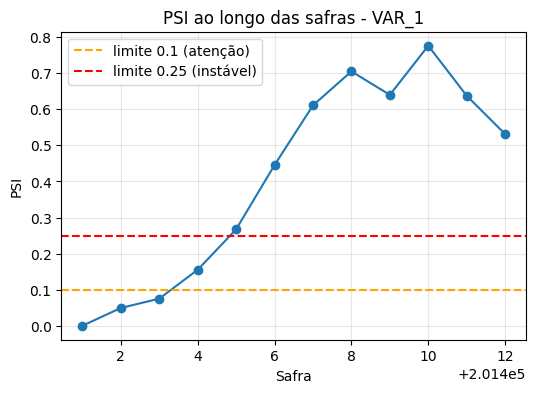

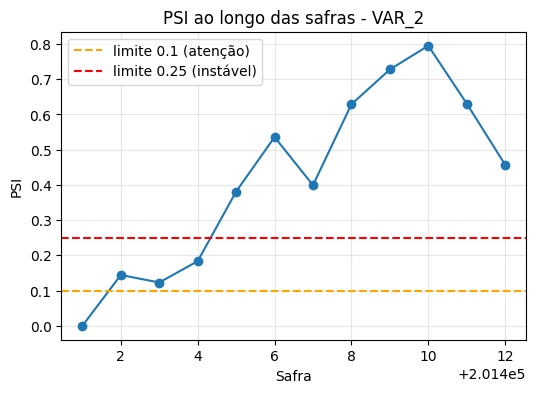

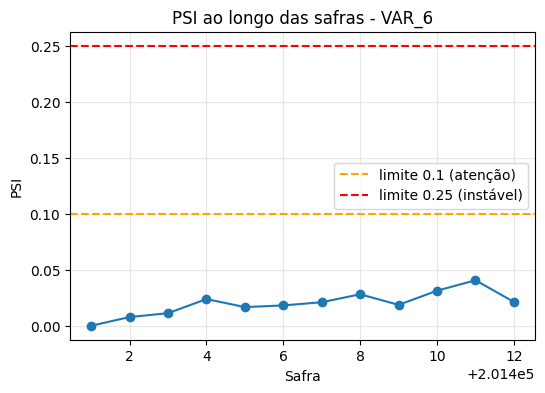

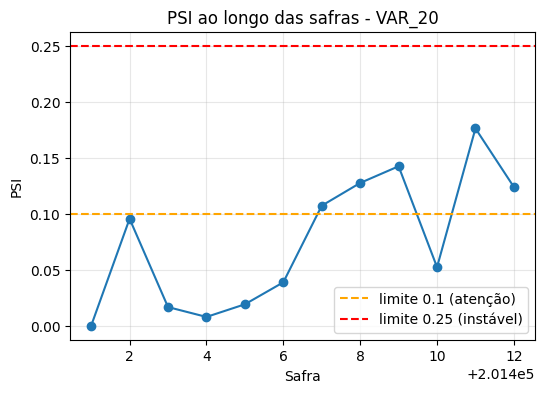

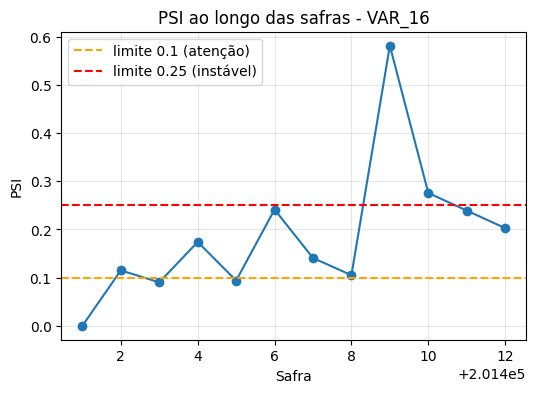

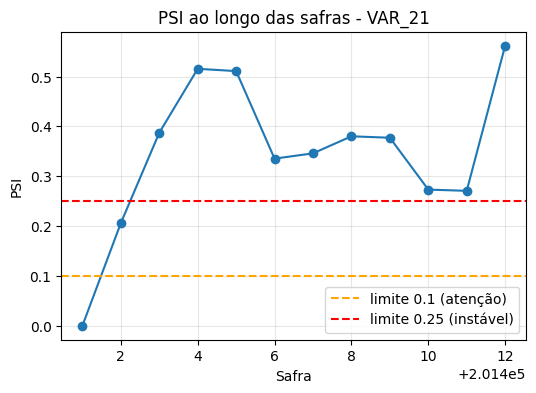

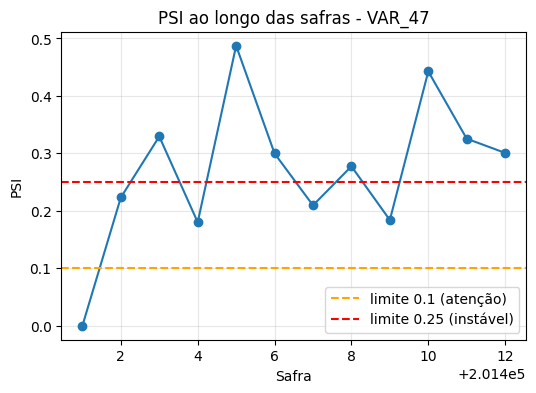

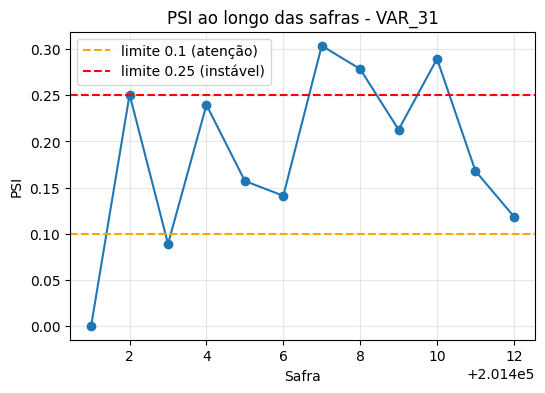

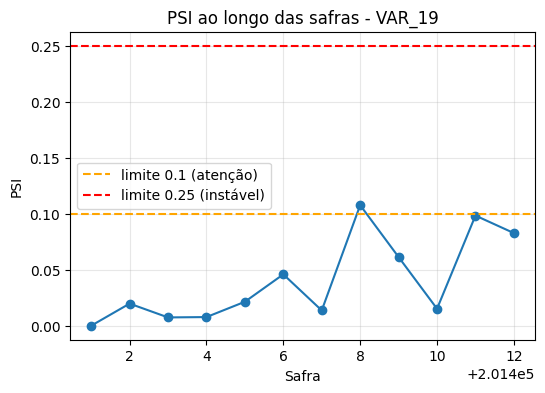

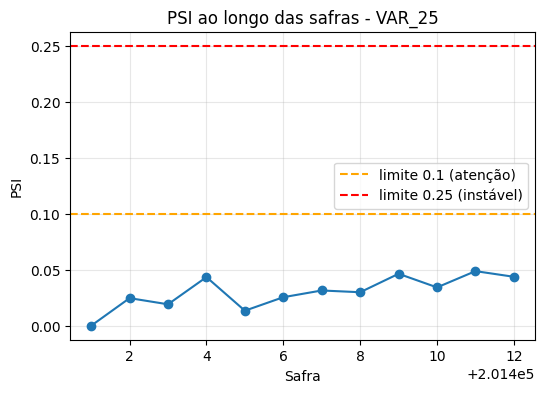

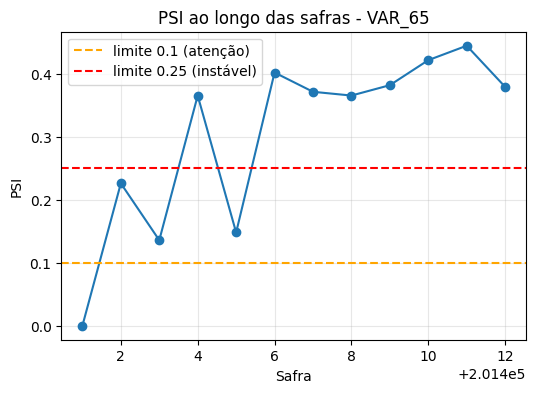

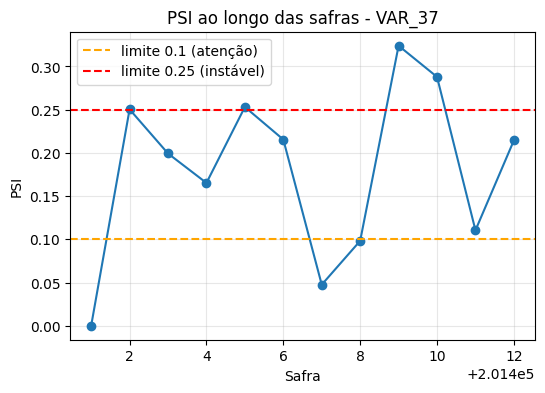

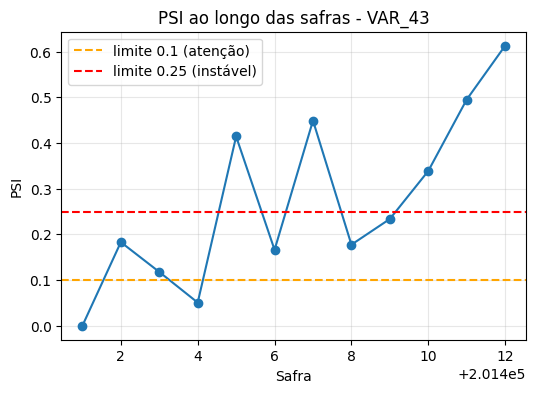

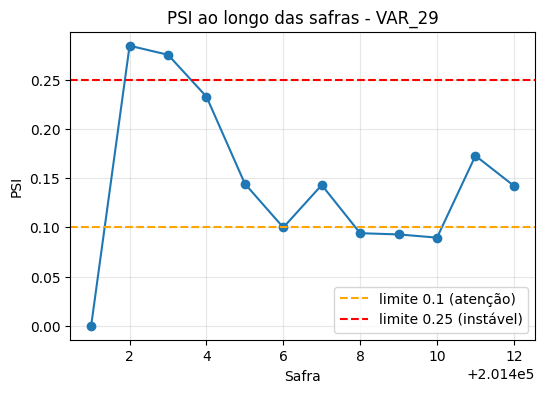

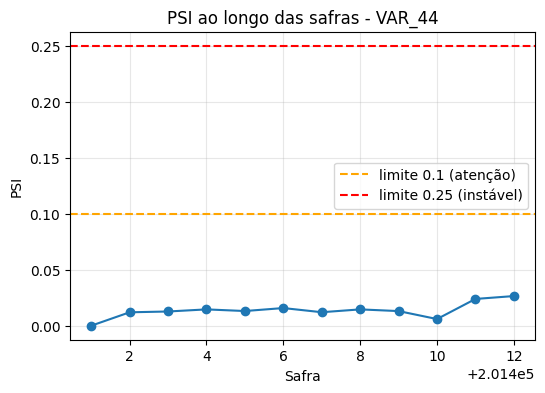

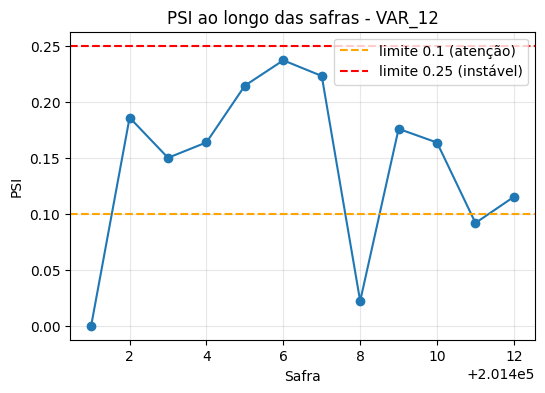

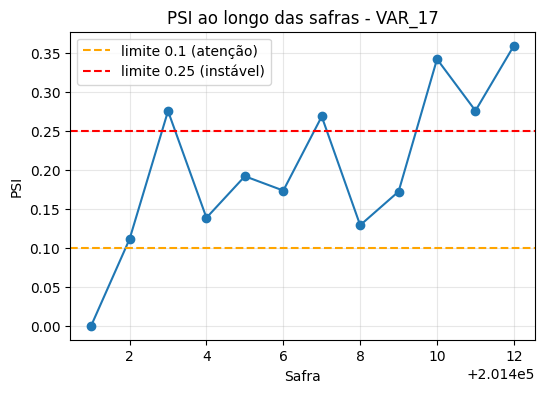

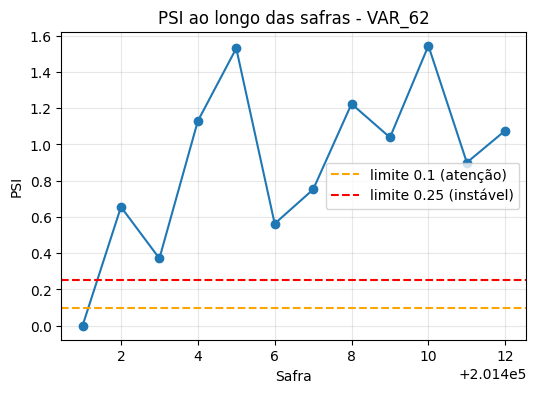

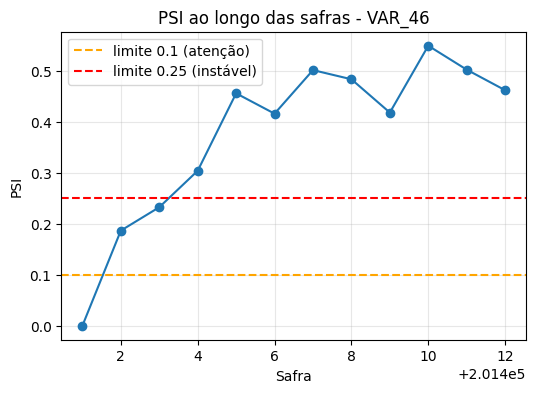

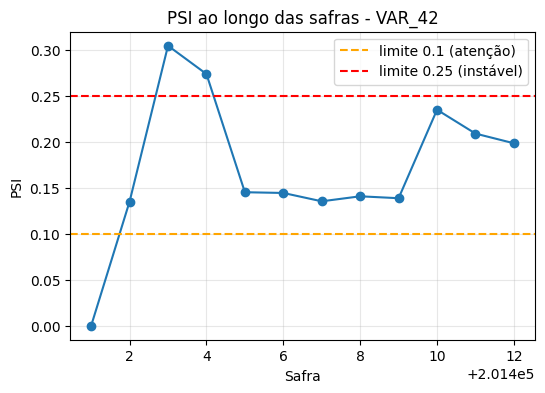

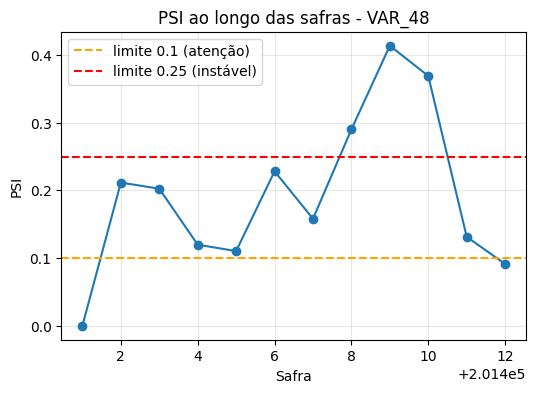

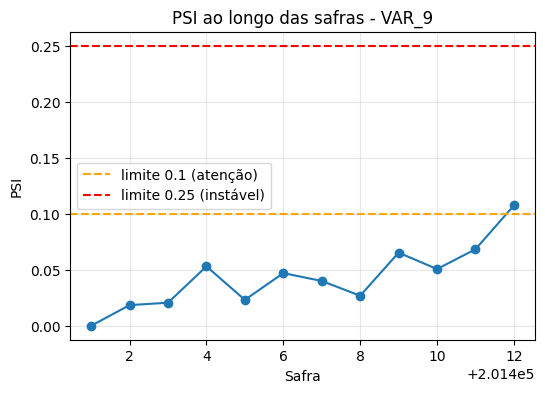

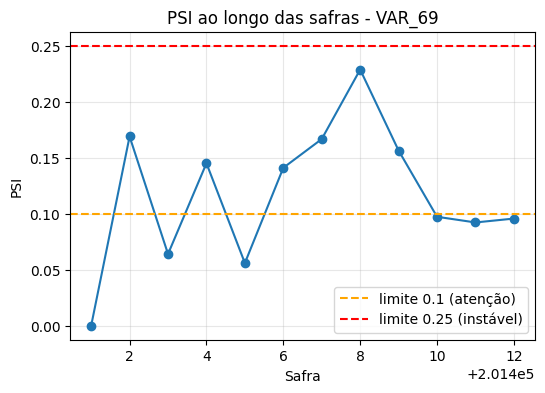

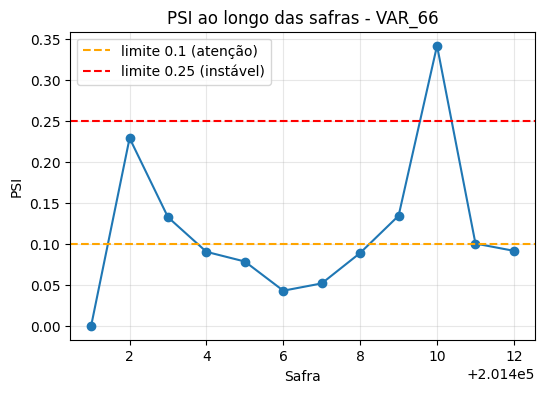

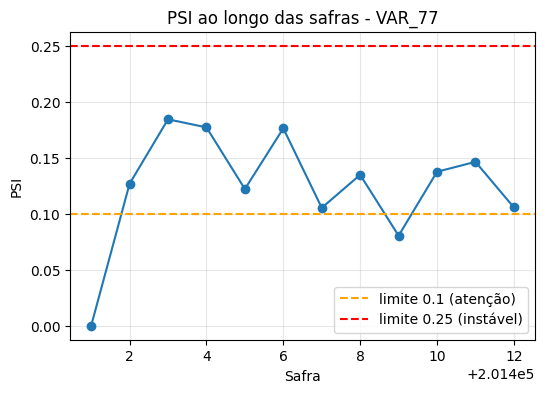

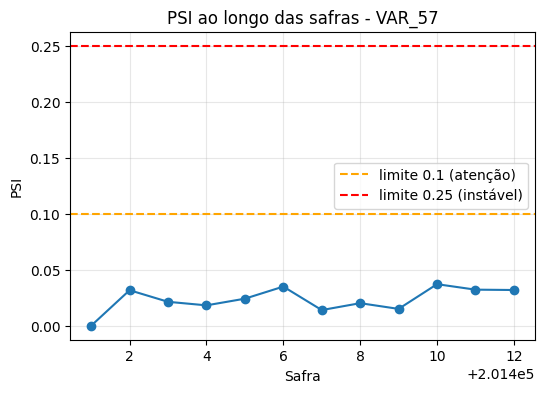

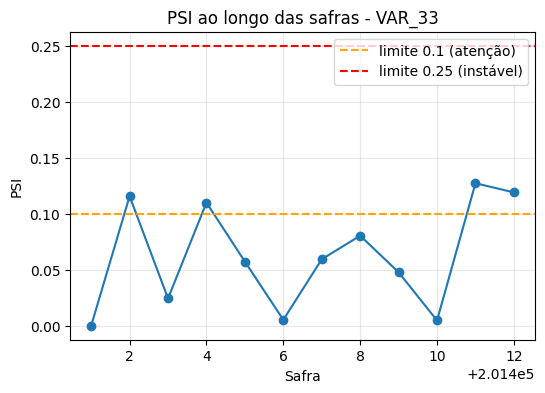

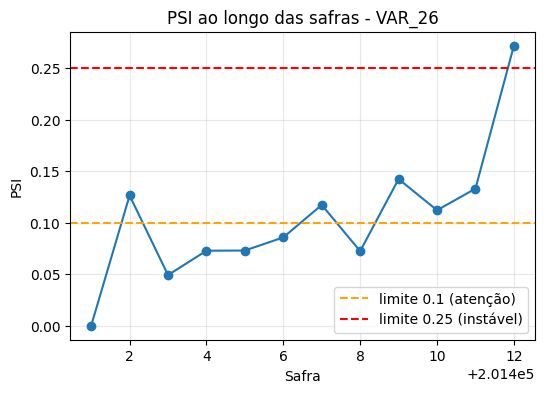

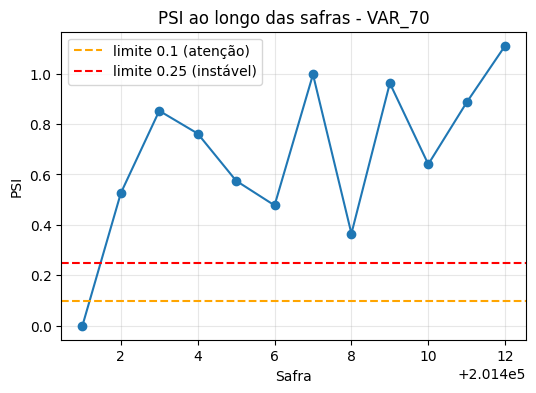

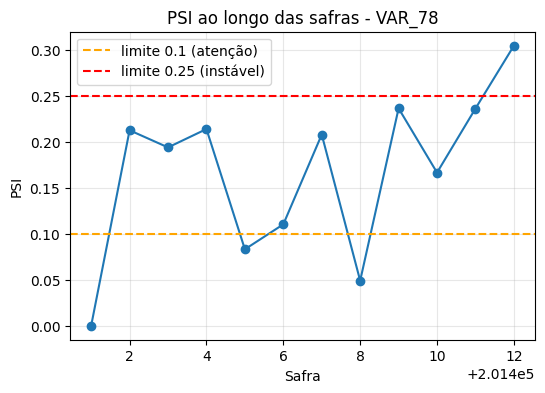

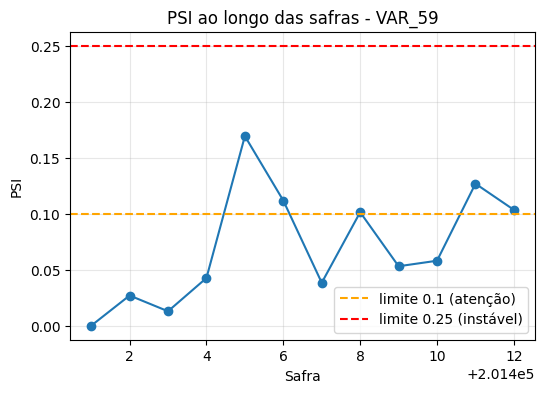

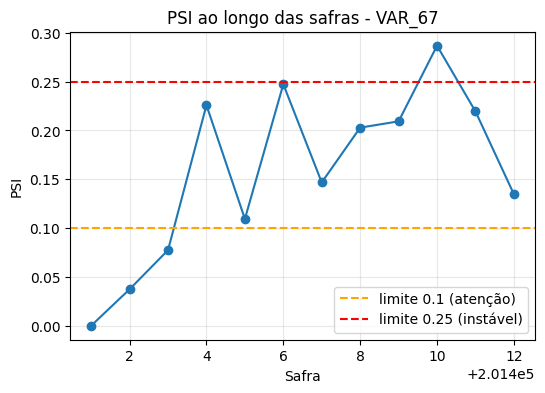

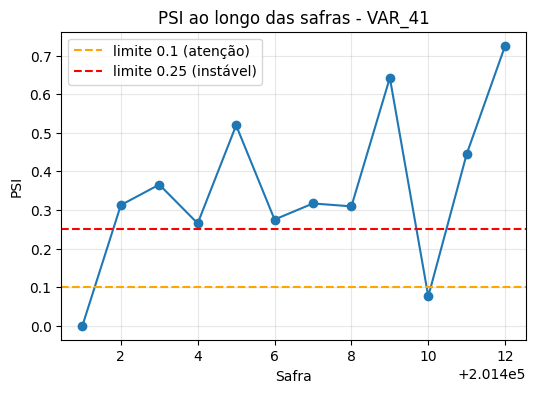

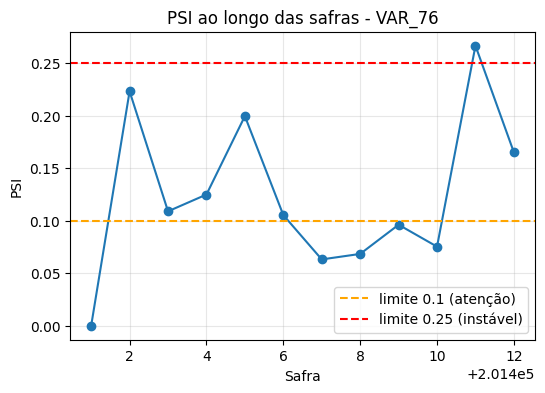

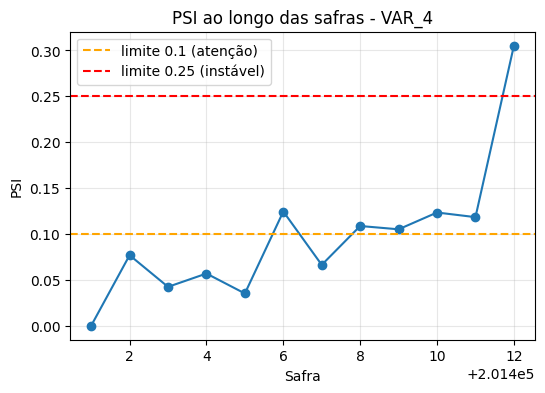

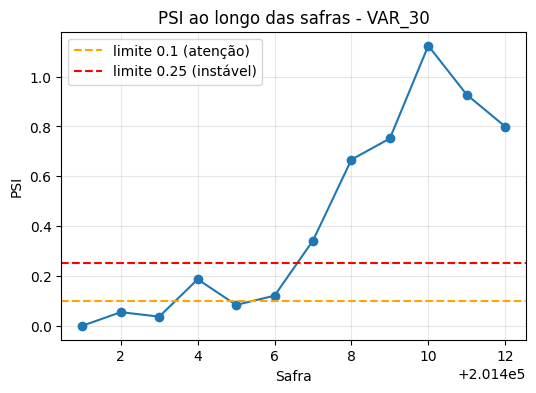

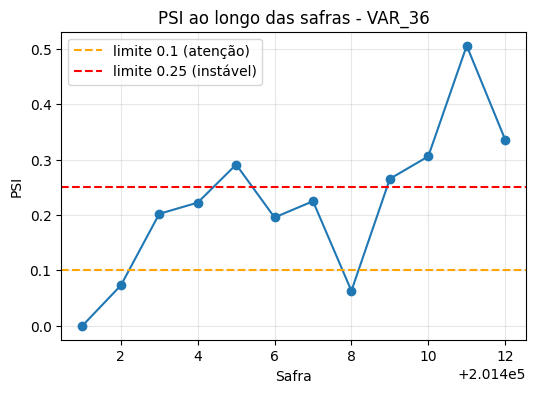

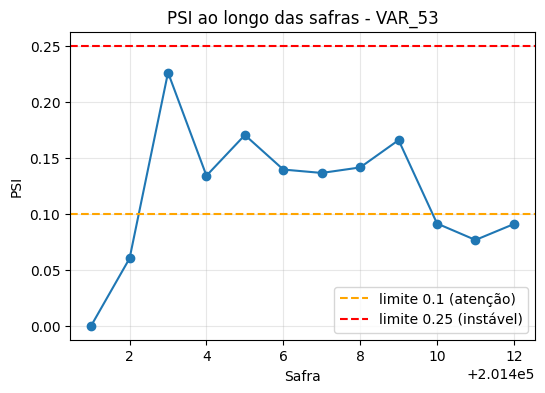

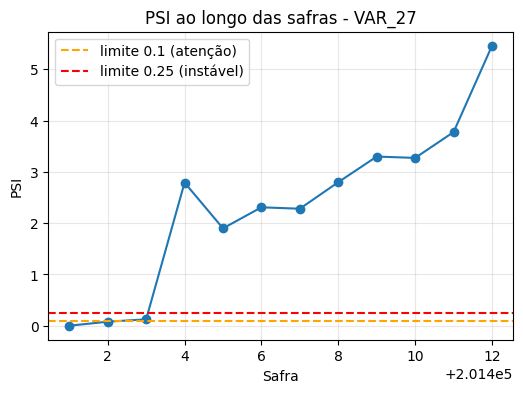

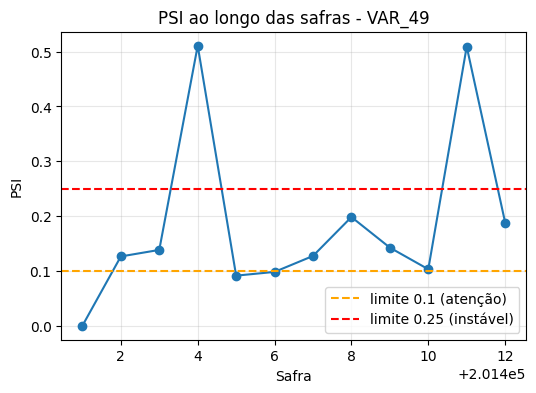

In [21]:
numeric_vars = [
    v for v in df_filter_iv_multicolinearity.select_dtypes(include=[np.number]).columns 
    if v not in ("y", "id", "safra")
]

psi_table = stability_analysis_all_vars(df_filter_iv_multicolinearity, numeric_vars, safra_col="safra")

Por fim, filtrando as variáveis com alto CSI, temos o dataset final 'df_filtered.csv'

In [22]:
unstable_vars = psi_table.max(axis=1)
unstable_vars = unstable_vars[unstable_vars > 0.25].index.tolist()

print("Variáveis instáveis (PSI > 0.25):")
unstable_vars

Variáveis instáveis (PSI > 0.25):


['VAR_1',
 'VAR_16',
 'VAR_17',
 'VAR_2',
 'VAR_21',
 'VAR_26',
 'VAR_27',
 'VAR_29',
 'VAR_30',
 'VAR_31',
 'VAR_36',
 'VAR_37',
 'VAR_4',
 'VAR_41',
 'VAR_42',
 'VAR_43',
 'VAR_46',
 'VAR_47',
 'VAR_48',
 'VAR_49',
 'VAR_62',
 'VAR_65',
 'VAR_66',
 'VAR_67',
 'VAR_70',
 'VAR_76',
 'VAR_78']

In [23]:
# remove columns listed in unstable_vars
df_filtered = df_filter_iv_multicolinearity.drop(columns=unstable_vars, errors='ignore')
df_filtered

,id,safra,y,VAR_6,VAR_20,VAR_19,VAR_25,VAR_44,VAR_12,VAR_9,VAR_69,VAR_77,VAR_57,VAR_33,VAR_59,VAR_53
0,1,201404,0,3277.0,8,45.0,12.0,11.0,299.0,500.00,156.38,0.00,45,18.0,95.54,3380.00
1,2,201407,0,2443.0,12,18.0,9.0,9.0,224.0,1000.00,707.84,54.00,60,13.0,97.73,1000.00
2,3,201405,0,1824.0,12,2.0,3.0,12.0,106.0,1893.35,471.86,121.98,31,2.0,294.57,1893.35
3,4,201412,0,3796.0,12,11.0,0.0,6.0,NaN,3000.00,119.96,0.00,76,3.0,NaN,3000.00
4,5,201403,1,437.0,12,0.0,0.0,0.0,NaN,2000.00,NaN,NaN,38,0.0,NaN,2946.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10733,10734,201406,0,515.0,10,0.0,0.0,0.0,NaN,500.00,NaN,NaN,27,0.0,NaN,500.00
10734,10735,201407,0,1029.0,12,0.0,0.0,10.0,91.0,1724.65,203.07,61.11,40,0.0,29.01,5524.65
10735,10736,201403,1,819.0,12,0.0,0.0,3.0,NaN,2759.03,260.00,0.00,45,0.0,369.46,3759.03
10736,10737,201402,1,1740.0,12,6.0,8.0,8.0,379.0,1000.00,447.77,92.91,28,2.0,319.33,2000.00


In [24]:
df_filtered.to_csv('../data/df_filtered.csv', header=True, index=False)